# Технологический практикум — первый этап

Коротчик Ярослав Юрьевич, группа 316. Сентябрь 2026.

Ячейки выполняются по порядку. Данные лежат в `datasets/`, весь код — в этом ноутбуке. Для запуска нужны Python 3.12, NumPy, pandas, SciPy, Matplotlib, scikit-learn и statsmodels.


## 1. Выбор данных и описание

Используем один источник — **NLSY97**, наблюдения за людьми, родившимися в 1980–1984 годах. Для всех расчётов выбраны 7 423 участника волны 2011 года.

| Представление | Период | Что рассматриваем |
|---|---|---|
| Таблица людей | Волна 2011, заработок за 2010 год | Образование, доходы, рост, масса, сон |
| Повторные опросы | 14 волн 2004–2023 | Заработок за 2003–2010, 2012, 2014, 2016, 2018, 2020, 2022 годы |
| Временной ряд | Январь 2004 — декабрь 2022, 228 месяцев | Доля работающих в выбранной когорте |

Отрицательные коды — пропуски. Нулевой заработок добавляем только при явном ответе «не получал». `None` — отсутствие степени, а `95 UNGRADED` — не число лет обучения. Сначала декодируем исходные файлы, затем считаем статистики.


In [1]:
from pathlib import Path
from io import BytesIO
import sys
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown
from statsmodels.stats.diagnostic import acorr_ljungbox

# При необходимости: %pip install numpy pandas scipy matplotlib scikit-learn statsmodels
DATA = Path('datasets')
TABLES, FIGURES = {}, {}

# Промежуточные таблицы и рисунки храним в памяти.
def table(frame, name, index=False):
    TABLES[name] = frame.reset_index() if index else frame.copy()
    return frame


def figure(fig, name):
    buffer = BytesIO()
    fig.savefig(buffer, format='png', bbox_inches='tight')
    FIGURES[name] = buffer.getvalue()
    plt.close(fig)


def show_figure(name):
    display(Image(data=FIGURES[name]))

SEED = 20260919
COLORS = ['#176B87', '#C05C34', '#548C55', '#785B9C', '#BD922E']
SERIES = {
    'employment_all': 'Все участники с известным статусом',
    'employment_men': 'Мужчины',
    'employment_women': 'Женщины',
    'employment_balanced': 'Полная история занятости',
}
FEATURES = {
    'age': 'Возраст, лет', 'highest_grade_completed': 'Завершённые годы обучения',
    'wage_income_2010_usd': 'Заработок за 2010 г., USD',
    'family_income_2010_usd': 'Семейный доход за 2010 г., USD',
    'job01_hours_per_week': 'Часы в неделю, работа № 01',
    'household_size': 'Размер домохозяйства', 'height_cm': 'Рост, см',
    'weight_kg': 'Масса тела, кг', 'sleep_hours_weeknight': 'Сон, часов',
}
EDUCATION = {0: 'Нет степени', 1: 'GED', 2: 'Школьный диплом', 3: 'Associate',
             4: 'Бакалавр', 5: 'Магистр', 6: 'PhD', 7: 'Профессиональная степень'}

pd.set_option('display.max_columns', 14)
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.precision', 4)
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': .18, 'figure.facecolor': 'white',
    'axes.prop_cycle': matplotlib.cycler(color=COLORS), 'savefig.dpi': 170,
})


In [2]:
import json

# Волна 2011: декодирование исходных столбцов и перевод единиц.
metadata = json.loads((DATA/'nlsy97/variables.json').read_text())
rename = {v['raw_column']: v['column'] for v in metadata['variables'] if 'raw_column' in v}
raw = pd.read_csv(DATA/'nlsy97/nlsy97_2011_selected_raw.csv').rename(columns=rename)
assert raw.person_id.is_unique and len(raw) == 8984
raw = raw.loc[raw.sampling_weight_raw.gt(0)].reset_index(drop=True)
missing_codes = raw.where(raw.lt(0))
nls = raw.mask(raw.lt(0)).copy()
nls['person_id'] = nls.person_id.astype(int)
nls['education'] = nls.education_code.map(EDUCATION)
nls['sex'] = nls.sex_code.map({1: 'Male', 2: 'Female'})
nls['sampling_weight'] = nls.sampling_weight_raw / 100
nls['height_cm'] = (12*nls.height_feet + nls.height_inches_part)*2.54
nls['weight_kg'] = nls.weight_lb*0.45359237
nls['wage_income_2010_usd'] = nls.wage_income_2010_reported_usd
no_wage = nls.received_wage_income_2010.eq(0) & nls.wage_income_2010_usd.isna()
nls.loc[no_wage, 'wage_income_2010_usd'] = 0
nls['wage_income_value_source'] = np.select(
    [no_wage, nls.wage_income_2010_reported_usd.notna()],
    ['explicit_no_wage_income', 'reported'], default='missing')
nls_before = nls.copy()
nls['grade_ungraded'] = nls.highest_grade_completed.eq(95)
nls.loc[nls.grade_ungraded, 'highest_grade_completed'] = np.nan
assert len(nls) == 7423

# Повторные опросы: год дохода взят из текста соответствующего вопроса.
panel_meta = json.loads((DATA/'nlsy97/panel_variables.json').read_text())
panel_raw = pd.read_csv(DATA/'nlsy97/income_waves_raw.csv.gz').set_index('R0000100')
assert panel_raw.index.is_unique
panel_raw = panel_raw.loc[nls.person_id]
parts = []
for wave in panel_meta['waves']:
    variables = [v for v in panel_meta['variables'] if v['survey_year'] == wave]
    mapping = {v['raw_column']: v['column'] for v in variables}
    part = panel_raw[list(mapping)].rename(columns=mapping).copy()
    part.index.name = 'person_id'
    part['participated'] = part.weight_raw.gt(0)
    part['income_year'] = next(v['income_year'] for v in variables if v['column'] == 'wage_reported')
    part['survey_year'] = wave
    wage = part.wage_reported.where(part.wage_reported.ge(0))
    wage = wage.mask(part.received_wage.eq(0) & wage.isna(), 0)
    part['wage_usd'] = wage.where(part.participated)
    for col in ['age', 'education_code']:
        part[col] = part[col].where(part[col].ge(0) & part.participated)
    parts.append(part.reset_index())
income_panel = pd.concat(parts, ignore_index=True)
assert not income_panel.duplicated(['person_id', 'survey_year']).any()
# Повторный срез должен совпадать с отдельно подготовленными данными 2011 года.
check_2011 = income_panel.query('survey_year == 2011').set_index('person_id').wage_usd
np.testing.assert_allclose(check_2011.loc[nls.person_id], nls.wage_income_2010_usd, equal_nan=True)

# Месячная точка = статус на неделе, содержащей 15-е число.
# Недели NLSY97 заданы официальным календарём, это не ISO-нумерация.
calendar = pd.read_csv(DATA/'nlsy97/monthly_calendar.csv', parse_dates=['date', 'week_start', 'week_end'])
anchors = calendar.date + pd.Timedelta(days=14)
assert (calendar.week_start.le(anchors) & calendar.week_end.ge(anchors)).all()
weekly = pd.read_csv(DATA/'nlsy97/employment_weeks_raw.csv.gz').set_index('R0000100')
assert weekly.index.is_unique
weekly = weekly.loc[nls.person_id, calendar.raw_column].copy()
weekly.columns = pd.DatetimeIndex(calendar.date, name='date')
assert np.isin(weekly.to_numpy(), [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6]).all() or (
    weekly.isin([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6]) | weekly.ge(9701)).all().all()
# 9701+ = работа у работодателя/самозанятость; 2,4,5 = не работал.
# 0,1,3,6 и отрицательные коды исключаем: неизвестный/неоднозначный статус или армия.
known = weekly.ge(9701) | weekly.isin([2, 4, 5])
employed = weekly.ge(9701).astype(float).where(known)
balanced_ids = employed.index[employed.notna().all(axis=1)]
sex = nls.set_index('person_id').sex_code
groups = {'employment_all': employed.index,
          'employment_men': sex.index[sex.eq(1)],
          'employment_women': sex.index[sex.eq(2)],
          'employment_balanced': balanced_ids}
assert len(balanced_ids) > 0
employment = pd.DataFrame({key: 100*employed.loc[ids].mean(axis=0) for key, ids in groups.items()})
coverage = pd.DataFrame({key: employed.loc[ids].count(axis=0) for key, ids in groups.items()})
assert employment.index.equals(pd.date_range('2004-01-01', '2022-12-01', freq='MS', name='date'))
assert employment.notna().all().all() and employment.stack().between(0, 100).all()
table(coverage, 'employment_coverage', index=True)
table(employment, 'employment_monthly', index=True)
print(f'{len(nls)} участников; {income_panel.survey_year.nunique()} волн; {len(employment)} месяцев; seed={SEED}')
print(f'Статус известен во всех месяцах для {len(balanced_ids)} человек.')
display(nls[['person_id', 'age', 'education', 'wage_income_2010_usd']].head())
display(employment.iloc[[0, -1]])


7423 участников; 14 волн; 228 месяцев; seed=20260919
Статус известен во всех месяцах для 5219 человек.


,person_id,age,education,wage_income_2010_usd
0,1,29.0,Бакалавр,50000.0
1,2,29.0,Школьный диплом,81000.0
2,3,28.0,Associate,NaN
3,4,30.0,Школьный диплом,51000.0
4,5,28.0,Школьный диплом,68000.0


,employment_all,employment_men,employment_women,employment_balanced
date,,,,
2004-01-01,66.8300,67.2247,66.4456,67.3117
2022-12-01,81.7183,85.6008,78.1029,82.6212


,check,n,action
0,grade_95,8,"95 UNGRADED: NaN в числовой шкале, отдельный флаг"
1,no_degree,745,"Категория «Нет степени», не пропуск"
2,education_missing,38,Настоящий пропуск категории
3,wage_explicit_zero,1516,Известный ноль сохранён
4,wage_topcode,120,Опубликованная агрегированная верхняя группа
5,height_below_100cm,8,"Флаг проверки единиц/анкеты, не удаление"
6,weight_below_20kg,2,"Флаг проверки анкеты, не медицинский диагноз"
7,employment_missing_months,0,Проверка календарной сетки


,education,n
0,Школьный диплом,3272
1,Бакалавр,1465
2,GED,934
3,Нет степени,745
4,Associate,537
5,Магистр,345
6,Профессиональная степень,73
7,Пропуск,38
8,PhD,14


,feature,count,mean,std,min,25%,50%,75%,max,missing,missing_percent,unique_observed,skew
0,age,7423.0,28.7424,1.4622,26.0000,28.0000,29.0000,30.0000,32.0000,0,0.0000,7,-0.0121
1,highest_grade_completed,7337.0,13.5003,2.9227,5.0000,12.0000,13.0000,16.0000,20.0000,86,1.1586,16,0.1379
2,wage_income_2010_usd,6818.0,26567.2806,26767.6929,0.0000,2400.0000,23000.0000,40000.0000,146002.0000,605,8.1503,447,1.7764
3,family_income_2010_usd,6528.0,63160.0656,58181.1798,0.0000,26000.0000,50000.0000,82000.0000,316618.0000,895,12.0571,2474,2.3665
4,job01_hours_per_week,6128.0,37.0795,13.3725,0.0000,32.0000,40.0000,40.0000,168.0000,1295,17.4458,77,0.3169
5,household_size,7423.0,3.2611,1.6642,1.0000,2.0000,3.0000,4.0000,15.0000,0,0.0000,14,0.9918
6,height_cm,7248.0,171.3782,11.4023,33.0200,162.5600,170.1800,180.3400,243.8400,175,2.3575,46,-0.6482
7,weight_kg,7186.0,83.1150,21.9941,0.4536,68.0389,79.3787,95.2544,214.0956,237,3.1928,259,1.0115
8,sleep_hours_weeknight,7395.0,6.6534,1.3764,0.0000,6.0000,7.0000,8.0000,16.0000,28,0.3772,17,-0.0720


,feature,count,mean,std,min,25%,50%,75%,max,missing,missing_percent,unique_observed,skew
0,employment_all,228.0,76.5997,2.9530,66.8300,74.6196,77.1121,78.5405,81.9121,0,0.0,228,-0.7056
1,employment_men,228.0,80.1314,3.7853,67.2247,77.7064,80.8862,83.1531,85.8425,0,0.0,226,-0.9940
2,employment_women,228.0,73.1636,2.5206,66.4456,71.2267,72.8633,74.8726,78.5375,0,0.0,227,0.0024
3,employment_balanced,228.0,77.8577,3.0509,67.3117,75.8191,78.5783,79.8573,82.7170,0,0.0,181,-0.9376


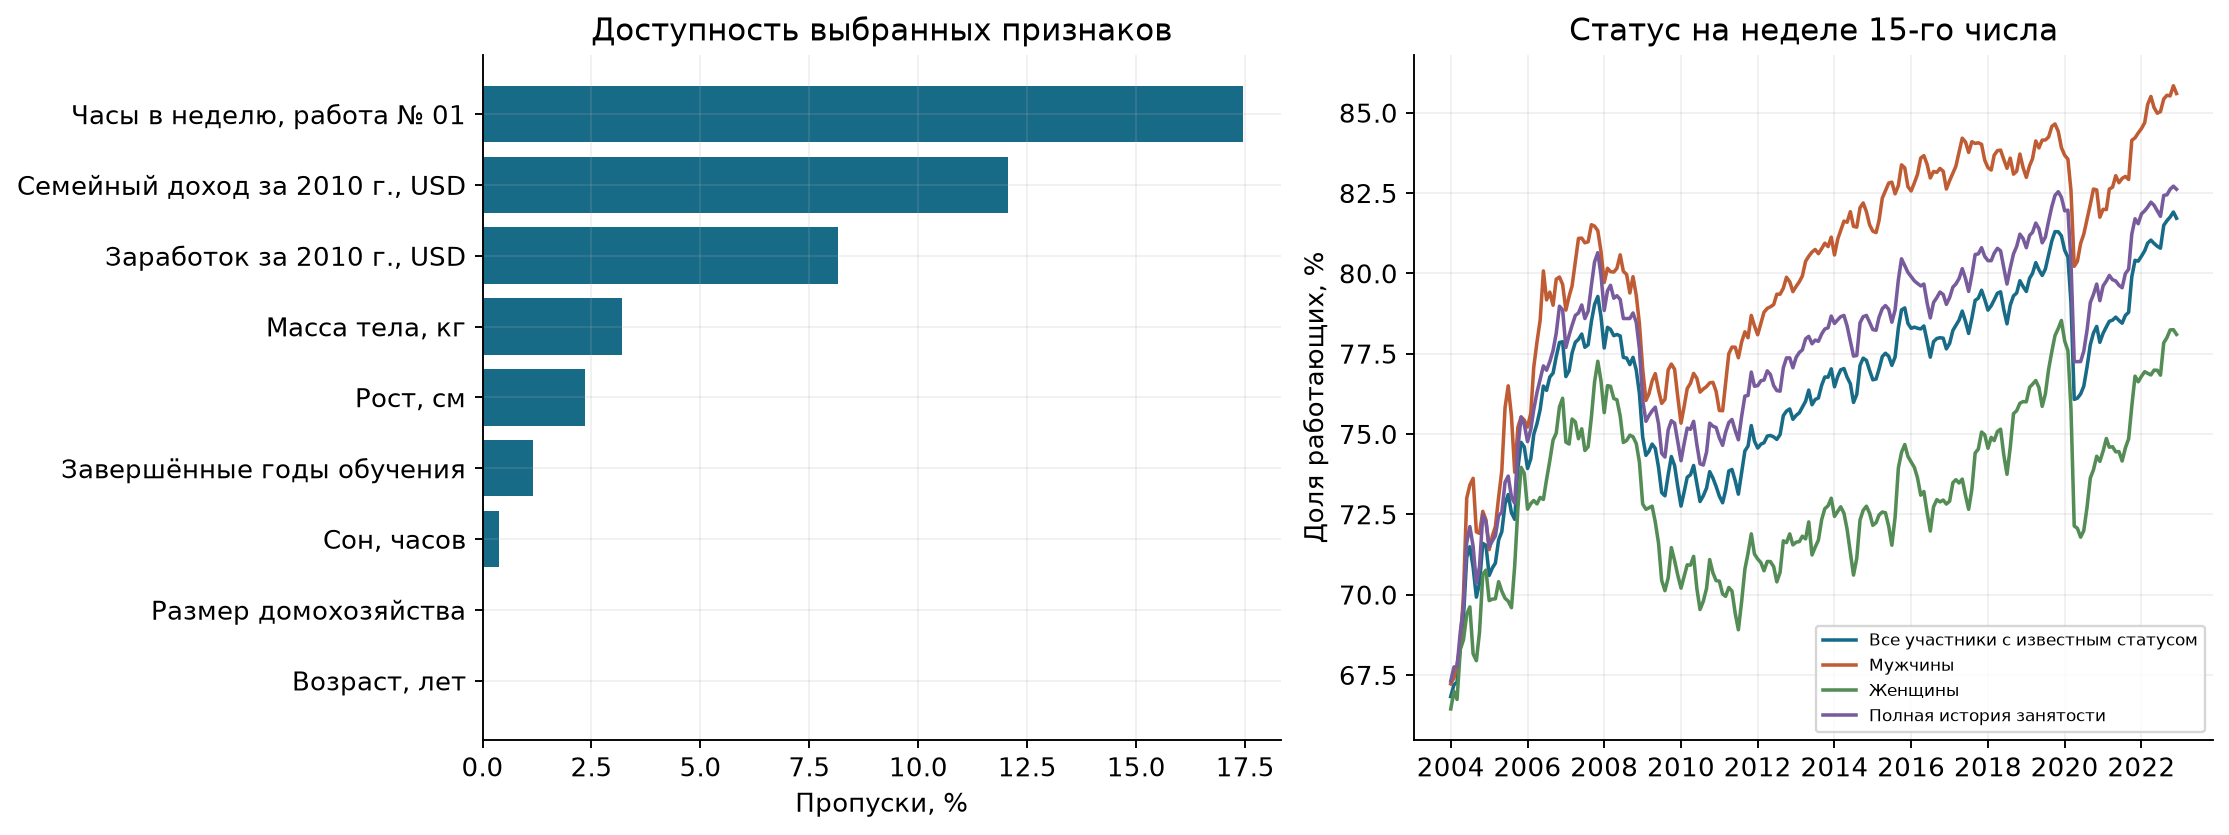

In [3]:
def descriptive(nls, employment, raw):
    def describe(df):
        r = df.describe(percentiles=[.25, .5, .75]).T
        r['missing'] = df.isna().sum()
        r['missing_percent'] = 100*df.isna().mean()
        r['unique_observed'] = df.nunique()
        r['skew'] = df.skew()
        return r.rename_axis('feature').reset_index()
    nls_summary = table(describe(nls[list(FEATURES)]), 'nls_summary')
    employment_summary = table(describe(employment), 'employment_summary')
    causes = []
    for c in ['highest_grade_completed','wage_income_2010_reported_usd','family_income_2010_usd',
              'height_feet','height_inches_part','weight_lb','job01_hours_per_week']:
        for code, count in missing_codes[c].value_counts().items():
            causes.append(dict(feature=c, code=int(code), n=int(count)))
    table(pd.DataFrame(causes), 'missing_reasons')
    audit = pd.DataFrame([
        ['grade_95', int(raw.highest_grade_completed.eq(95).sum()), '95 UNGRADED: NaN в числовой шкале, отдельный флаг'],
        ['no_degree', int(nls.education_code.eq(0).sum()), 'Категория «Нет степени», не пропуск'],
        ['education_missing', int(nls.education_code.isna().sum()), 'Настоящий пропуск категории'],
        ['wage_explicit_zero', int(nls.wage_income_value_source.eq('explicit_no_wage_income').sum()), 'Известный ноль сохранён'],
        ['wage_topcode', int(nls.wage_income_2010_usd.eq(146002).sum()), 'Опубликованная агрегированная верхняя группа'],
        ['height_below_100cm', int(nls.height_cm.lt(100).sum()), 'Флаг проверки единиц/анкеты, не удаление'],
        ['weight_below_20kg', int(nls.weight_kg.lt(20).sum()), 'Флаг проверки анкеты, не медицинский диагноз'],
        ['employment_missing_months', int(employment.isna().all(axis=1).sum()), 'Проверка календарной сетки'],
    ], columns=['check','n','action'])
    table(audit, 'data_audit')
    weighted = []
    for c in FEATURES:
        pair = nls[[c,'sampling_weight']].dropna()
        weighted.append(dict(feature=c, mean=pair[c].mean(), weighted_mean=np.average(pair[c], weights=pair.sampling_weight), n=len(pair)))
    table(pd.DataFrame(weighted), 'weighted_sensitivity')
    education = table(nls.education.fillna('Пропуск').value_counts().rename_axis('education').reset_index(name='n'), 'education_counts')
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), layout='constrained')
    vals = nls_summary.set_index('feature').missing_percent.sort_values()
    axes[0].barh([FEATURES[x] for x in vals.index], vals, color=COLORS[0])
    axes[0].set(xlabel='Пропуски, %', title='Доступность выбранных признаков')
    for c, label in SERIES.items():
        axes[1].plot(employment.index, employment[c], label=label, lw=1.5)
    axes[1].set(ylabel='Доля работающих, %', title='Статус на неделе 15-го числа')
    axes[1].legend(fontsize=7, loc='lower right')
    figure(fig, '01_overview')
    # До первого пропуска: никакой склейки соседей через неизвестный месяц.
    prefix = employment.loc[:employment.index[employment.isna().any(axis=1)][0]-pd.offsets.MonthBegin(1)] if employment.isna().any().any() else employment
    dependence = []
    for c in employment:
        for transform, x in [('level', prefix[c]), ('difference', prefix[c].diff().dropna())]:
            lb = acorr_ljungbox(x, lags=[12], return_df=True).iloc[0]
            dependence.append(dict(series=c, transform=transform, n=len(x), acf1=x.autocorr(1),
                                   ljung_box_12=float(lb.lb_stat), diagnostic_p=float(lb.lb_pvalue)))
    dep = table(pd.DataFrame(dependence), 'time_dependence')
    return dict(nls_summary=nls_summary, employment_summary=employment_summary, audit=audit, education=education, dependence=dep)

description = descriptive(nls, employment, nls_before)
display(description["audit"])
display(description["education"])
display(description["nls_summary"])
display(description["employment_summary"])
show_figure("01_overview")


In [4]:
wage = description["nls_summary"].set_index("feature").loc["wage_income_2010_usd"]
display(Markdown(
    f"**Результат.** Средний заработок ${wage['mean']:,.0f}, медиана ${wage['50%']:,.0f}. "
    f"Для {int(wage['missing'])} человек сумма неизвестна ({wage['missing_percent']:.2f}%). "
    "Среднее выше медианы, что согласуется с длинным правым хвостом. "
    "Минимумы роста и массы требуют проверки анкеты, но здесь не удаляются."
))
display(TABLES["weighted_sensitivity"])


**Результат.** Средний заработок $26,567, медиана $23,000. Для 605 человек сумма неизвестна (8.15%). Среднее выше медианы, что согласуется с длинным правым хвостом. Минимумы роста и массы требуют проверки анкеты, но здесь не удаляются.

,feature,mean,weighted_mean,n
0,age,28.7424,28.7823,7423
1,highest_grade_completed,13.5003,13.7943,7337
2,wage_income_2010_usd,26567.2806,29086.2359,6818
3,family_income_2010_usd,63160.0656,68339.3636,6528
4,job01_hours_per_week,37.0795,37.3916,6128
5,household_size,3.2611,3.1590,7423
6,height_cm,171.3782,172.0023,7248
7,weight_kg,83.1150,82.5427,7186
8,sleep_hours_weeknight,6.6534,6.6699,7395


Основные статистики описывают выбранных участников без весов; взвешенные средние для волны 2011 приведены для сравнения. Ниже — изменение заработка и занятости в той же когорте.

Доля работающих считается среди людей с известным гражданским статусом на неделе, содержащей 15-е число месяца. Неизвестный статус, неоднозначные коды и служба в армии исключены из знаменателя. Это характеристика выбранной когорты, не официальный показатель занятости США. Сезонная корректировка не применяется.

Дополнительно показываем людей с полной историей. Такой отбор тоже может быть смещённым. Автокорреляция нужна для оценки зависимости соседних месяцев.

,income_year,observed,median_usd,mean_usd,participating,balanced_median_usd,balanced_n
0,2003,5375,7500.0,10767.5181,6763,9000.0,1910
1,2004,5384,10000.0,13306.4734,6692,12000.0,1910
2,2005,5723,15000.0,16679.1141,6916,16000.0,1910
3,2006,5705,18000.0,20131.8785,6867,20000.0,1910
4,2007,6088,20000.0,23180.3546,7002,25000.0,1910
5,2008,6443,23000.0,24955.9946,7114,27000.0,1910
6,2009,6488,21000.0,24686.4592,7151,27000.0,1910
7,2010,6818,23000.0,26567.2806,7423,28000.0,1910
8,2012,6232,25000.0,30633.7503,6827,32950.0,1910
9,2014,5978,30000.0,35004.0701,6744,36000.0,1910


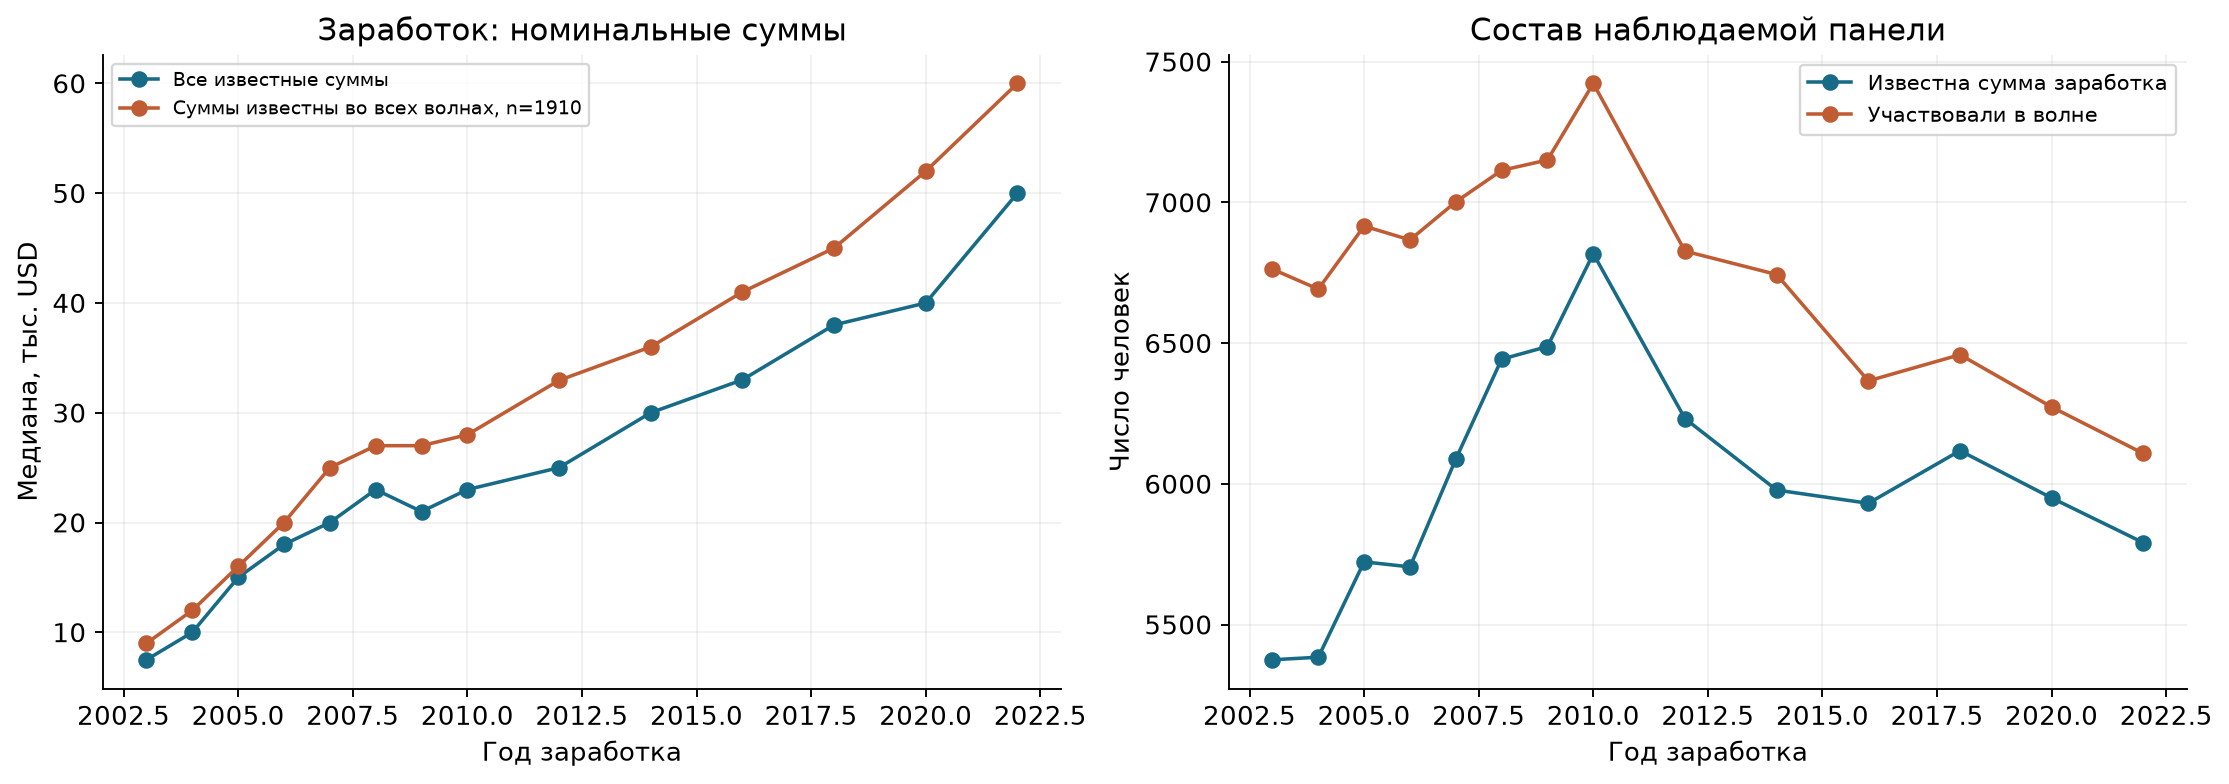

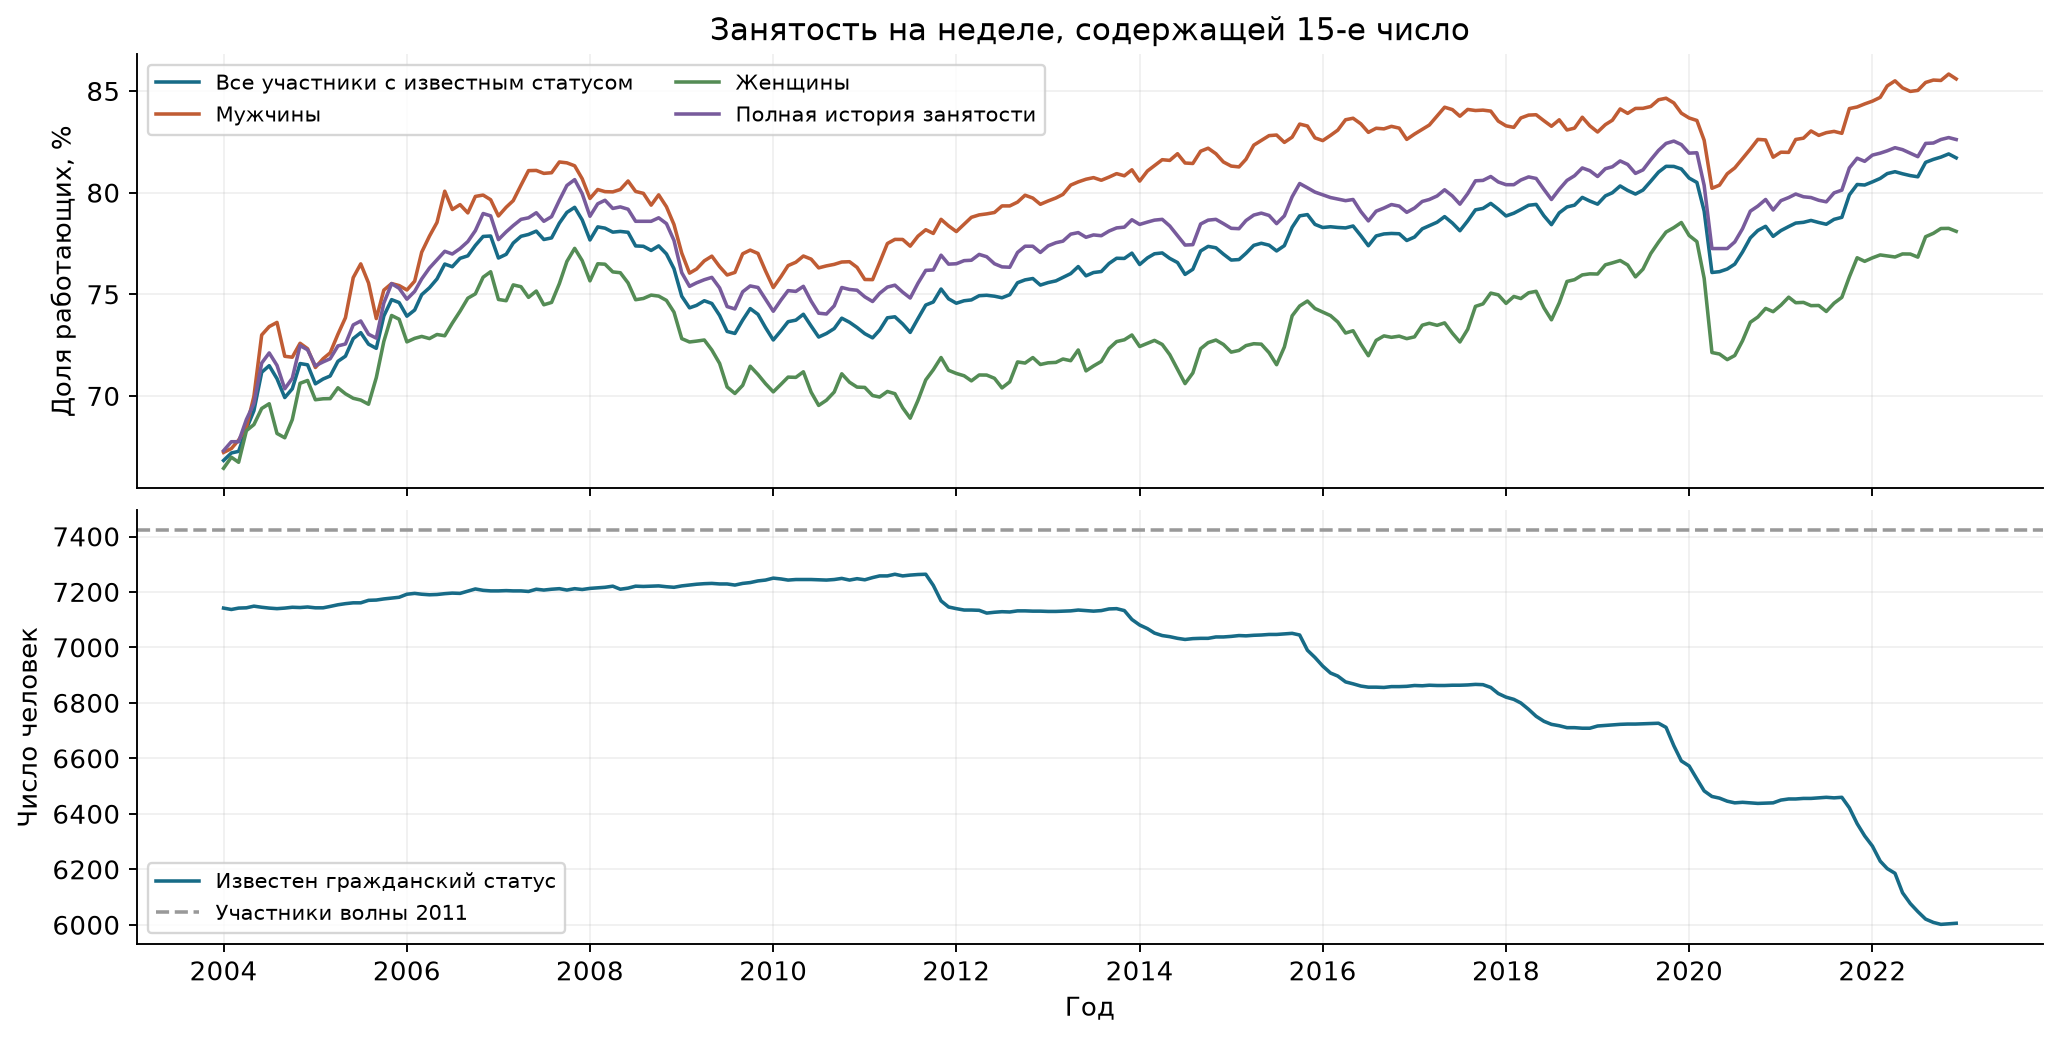

В каждом месяце статус известен для **6,002–7,264** участников. Заработок известен во всех 14 волнах для **1,910** человек. Линии соединяют наблюдаемые годы; отсутствующие годы заработка не восстанавливались. Доходы указаны без поправки на инфляцию. Рост также связан со взрослением когорты; выбор людей с полной историей может вносить смещение.

In [5]:
income_wide = income_panel.pivot(index='person_id', columns='income_year', values='wage_usd')
income_balanced = income_wide.dropna()
income_trends = income_panel.groupby('income_year').agg(
    observed=('wage_usd', 'count'), median_usd=('wage_usd', 'median'),
    mean_usd=('wage_usd', 'mean'), participating=('participated', 'sum')).reset_index()
income_trends['balanced_median_usd'] = income_trends.income_year.map(income_balanced.median())
income_trends['balanced_n'] = len(income_balanced)
table(income_trends, 'income_dynamics')
display(income_trends)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout='constrained')
axes[0].plot(income_trends.income_year, income_trends.median_usd/1000, '-o', label='Все известные суммы')
axes[0].plot(income_trends.income_year, income_trends.balanced_median_usd/1000, '-o',
             label=f'Суммы известны во всех волнах, n={len(income_balanced)}')
axes[0].set(xlabel='Год заработка', ylabel='Медиана, тыс. USD', title='Заработок: номинальные суммы')
axes[0].legend(fontsize=8)
axes[1].plot(income_trends.income_year, income_trends.observed, '-o', label='Известна сумма заработка')
axes[1].plot(income_trends.income_year, income_trends.participating, '-o', label='Участвовали в волне')
axes[1].set(xlabel='Год заработка', ylabel='Число человек', title='Состав наблюдаемой панели')
axes[1].legend(fontsize=9)
figure(fig, '11_income_dynamics')
show_figure('11_income_dynamics')

fig, axes = plt.subplots(2, 1, figsize=(12, 6), layout='constrained', sharex=True)
for key, label in SERIES.items():
    axes[0].plot(employment.index, employment[key], label=label, lw=1.5)
axes[0].set(ylabel='Доля работающих, %', title='Занятость на неделе, содержащей 15-е число')
axes[0].legend(ncols=2, fontsize=9)
axes[1].plot(coverage.index, coverage.employment_all, label='Известен гражданский статус')
axes[1].axhline(len(nls), color='#999999', ls='--', label='Участники волны 2011')
axes[1].set(xlabel='Год', ylabel='Число человек')
axes[1].legend(fontsize=9)
figure(fig, '12_employment_dynamics')
show_figure('12_employment_dynamics')
display(Markdown(
    f"В каждом месяце статус известен для **{coverage.employment_all.min():,}–"
    f"{coverage.employment_all.max():,}** участников. "
    f"Заработок известен во всех 14 волнах для **{len(income_balanced):,}** человек. "
    "Линии соединяют наблюдаемые годы; отсутствующие годы заработка не восстанавливались. "
    "Доходы указаны без поправки на инфляцию. Рост также связан со взрослением когорты; "
    "выбор людей с полной историей может вносить смещение."
))


In [6]:
display(description["dependence"])


,series,transform,n,acf1,ljung_box_12,diagnostic_p
0,employment_all,level,228,0.9856,1598.2101,0.0000e+00
1,employment_all,difference,227,0.3262,125.2697,5.4756e-21
2,employment_men,level,228,0.9889,1739.0607,0.0000e+00
3,employment_men,difference,227,0.2655,87.0141,1.8637e-13
4,employment_women,level,228,0.9694,1371.7688,1.6960e-286
5,employment_women,difference,227,0.3172,113.1357,1.4321e-18
6,employment_balanced,level,228,0.9849,1579.9150,0.0000e+00
7,employment_balanced,difference,227,0.3168,120.4920,4.9305e-20


Сравнение волн смешивает изменение доходов с возрастом и составом ответивших. Доходы номинальные, поэтому их рост нельзя целиком считать ростом покупательной способности. Нули и обработанный поставщиком верхний хвост сохранены. Связь образования с заработком не означает причинного эффекта.

## 2. Аппроксимация распределений с помощью ядерных оценок

Используем гауссово ядро и сравниваем ширины окна $h/2$, $h$ и $2h$, где $h=s n^{-1/5}$ — правило Скотта:

$$\hat f_h(x)=\frac{1}{nh}\sum_{i=1}^{n}\frac{1}{\sqrt{2\pi}}\exp\left(-\frac{(x-x_i)^2}{2h^2}\right).$$

Для положительных заработков строим KDE логарифма. При возврате к долларам $f_X(x)=f_{\log X}(\log x)/x$. Доля нулевых заработков учитывается отдельно.


In [7]:
def sample_1d(x, minimum=3):
    """Пропуски исключаются явно; бесконечности и константы запрещены."""
    a = np.asarray(x, dtype=float)
    if a.ndim != 1:
        raise ValueError("Ожидается одномерная выборка")
    a = a[~np.isnan(a)]
    if len(a) < minimum or not np.isfinite(a).all() or np.ptp(a) == 0:
        raise ValueError("Недостаточная, бесконечная или постоянная выборка")
    return a


def gaussian_kde_manual(x, grid, bandwidth):
    """f(x)=1/(nh) sum K((x-x_i)/h), гауссово ядро; h в единицах x."""
    a = sample_1d(x)
    if not np.isfinite(bandwidth) or bandwidth <= 0:
        raise ValueError("Ширина окна должна быть положительной")
    grid = np.asarray(grid, dtype=float)
    # Блоки ограничивают память, не меняя формулу.
    out = np.zeros_like(grid)
    for block in np.array_split(a, max(1, int(np.ceil(len(a) / 1000)))):
        out += stats.norm.pdf((grid[:, None] - block) / bandwidth).sum(axis=1)
    return out / (len(a) * bandwidth)


def density_analysis(nls, employment):
    """Сглаживание отделяем от гипотезы о механизме генерации данных."""
    wages = nls.wage_income_2010_usd.dropna()
    positive = wages[wages>0]
    y = np.log(positive)
    grid = np.linspace(y.min()-1, y.max()+1, 450)
    scott_h = y.std(ddof=1)*len(y)**(-.2)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), layout='constrained')
    axes[0].hist(y, bins=40, density=True, color='#D9E6EA')
    kde_values = {'log_wage':grid}
    for factor in [.5, 1, 2]:
        density = gaussian_kde_manual(y, grid, scott_h*factor)
        axes[0].plot(grid, density, label=f'h = {factor:g} × Scott')
        kde_values[f'factor_{factor}'] = density
    axes[0].set(title='Положительный заработок: выбор окна', xlabel='ln(заработок в USD)', ylabel='Плотность на шкале логарифма')
    axes[0].legend(fontsize=9)
    # Якобиан 1/x обязателен при обратном переходе от log к USD.
    dollars = np.linspace(50, 165000, 500)
    log_kde = stats.gaussian_kde(y)
    axes[1].plot(dollars/1000, log_kde(np.log(dollars))/dollars*1000, lw=2)
    axes[1].set(title='Плотность при условии заработка > 0', xlabel='Заработок, тыс. USD', ylabel='Плотность на 1000 USD')
    axes[1].text(.96,.94,f'P(заработок = 0) = {wages.eq(0).mean():.1%}\nсреди известных сумм',ha='right',va='top', transform=axes[1].transAxes,fontsize=9)
    for c,label in SERIES.items():
        x=employment[c].dropna()
        gx=np.linspace(0,100,500)
        kernel=stats.gaussian_kde(x)
        # Отражение у 0 и 100 уменьшает граничное смещение для долей.
        axes[2].plot(gx,kernel(gx)+kernel(-gx)+kernel(200-gx), label=label)
    axes[2].set(title='Занятость: распределение по месяцам', xlabel='Доля работающих, %', ylabel='Плотность на процентный пункт')
    axes[2].legend(fontsize=7)
    figure(fig,'02_kde')
    table(pd.DataFrame(kde_values),'kde_bandwidth')
    table(pd.DataFrame({'wage_usd':dollars,'positive_density_per_usd':log_kde(np.log(dollars))/dollars}),'kde_positive_wage')
    return dict(zero_fraction=float(wages.eq(0).mean()),scott_bandwidth=float(scott_h),positive_n=len(positive))


Максимальное расхождение собственной и библиотечной KDE: 1.0325074129013956e-14


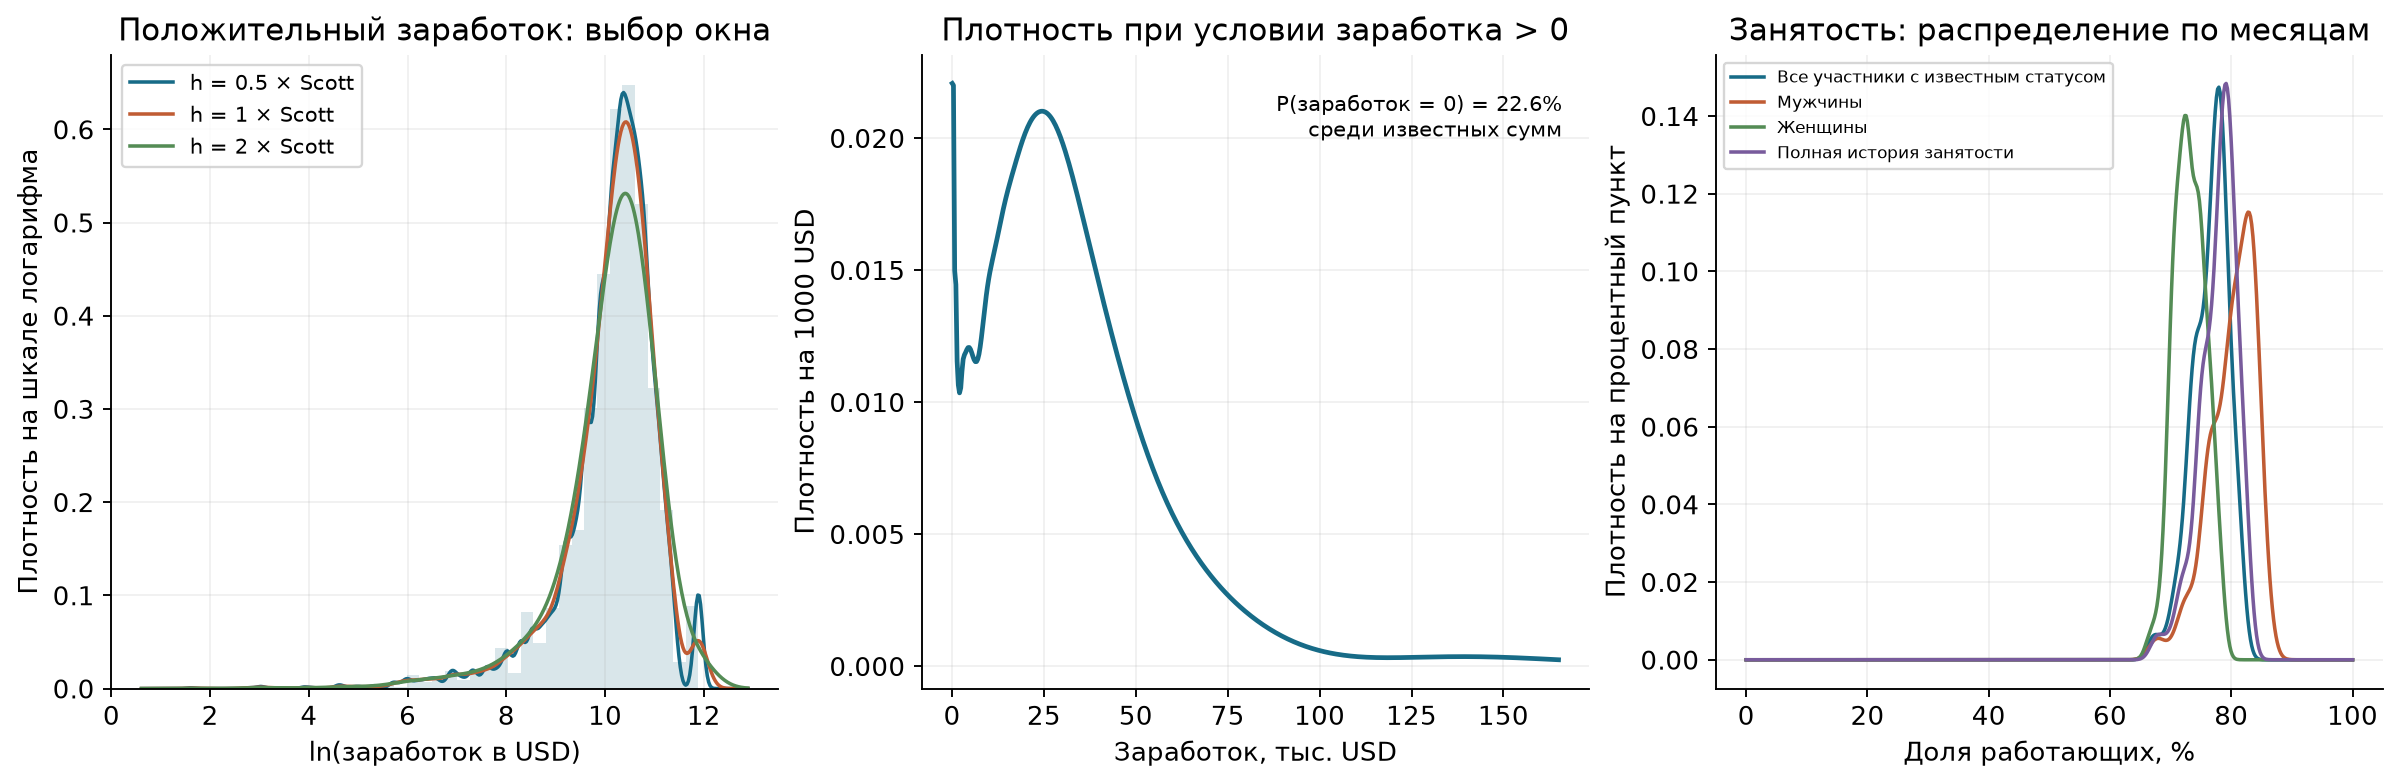

In [8]:
# Прямой контроль реализации формулы относительно библиотечной KDE.
positive = nls.loc[nls.wage_income_2010_usd.gt(0), "wage_income_2010_usd"]
log_wage = np.log(positive).to_numpy()
h = log_wage.std(ddof=1) * len(log_wage) ** (-1/5)
grid = np.linspace(log_wage.min()-1, log_wage.max()+1, 500)
manual = gaussian_kde_manual(log_wage, grid, h)
library = stats.gaussian_kde(log_wage, bw_method=h/log_wage.std(ddof=1))(grid)
print("Максимальное расхождение собственной и библиотечной KDE:", np.max(np.abs(manual-library)))
assert np.allclose(manual, library, atol=1e-12)
density = density_analysis(nls, employment)
show_figure("02_kde")


In [9]:
print(f"Доля нулевых заработков: {density['zero_fraction']:.2%}; положительных сумм: {density['positive_n']}")


Доля нулевых заработков: 22.59%; положительных сумм: 5278


При увеличении окна оценка становится более гладкой и теряет локальные детали. KDE занятости описывает частоту уровней, но не порядок месяцев. Для долей применено отражение у границ 0 и 100%.

## 3. Условные плотности, одномерные точечные диаграммы и диаграммы размаха

Сравним заработки внутри образовательных групп и рост по полу. Каждая условная плотность имеет площадь 1. В boxplot включены нулевые доходы; сдвиг точек роста по вертикали нужен только для читаемости.


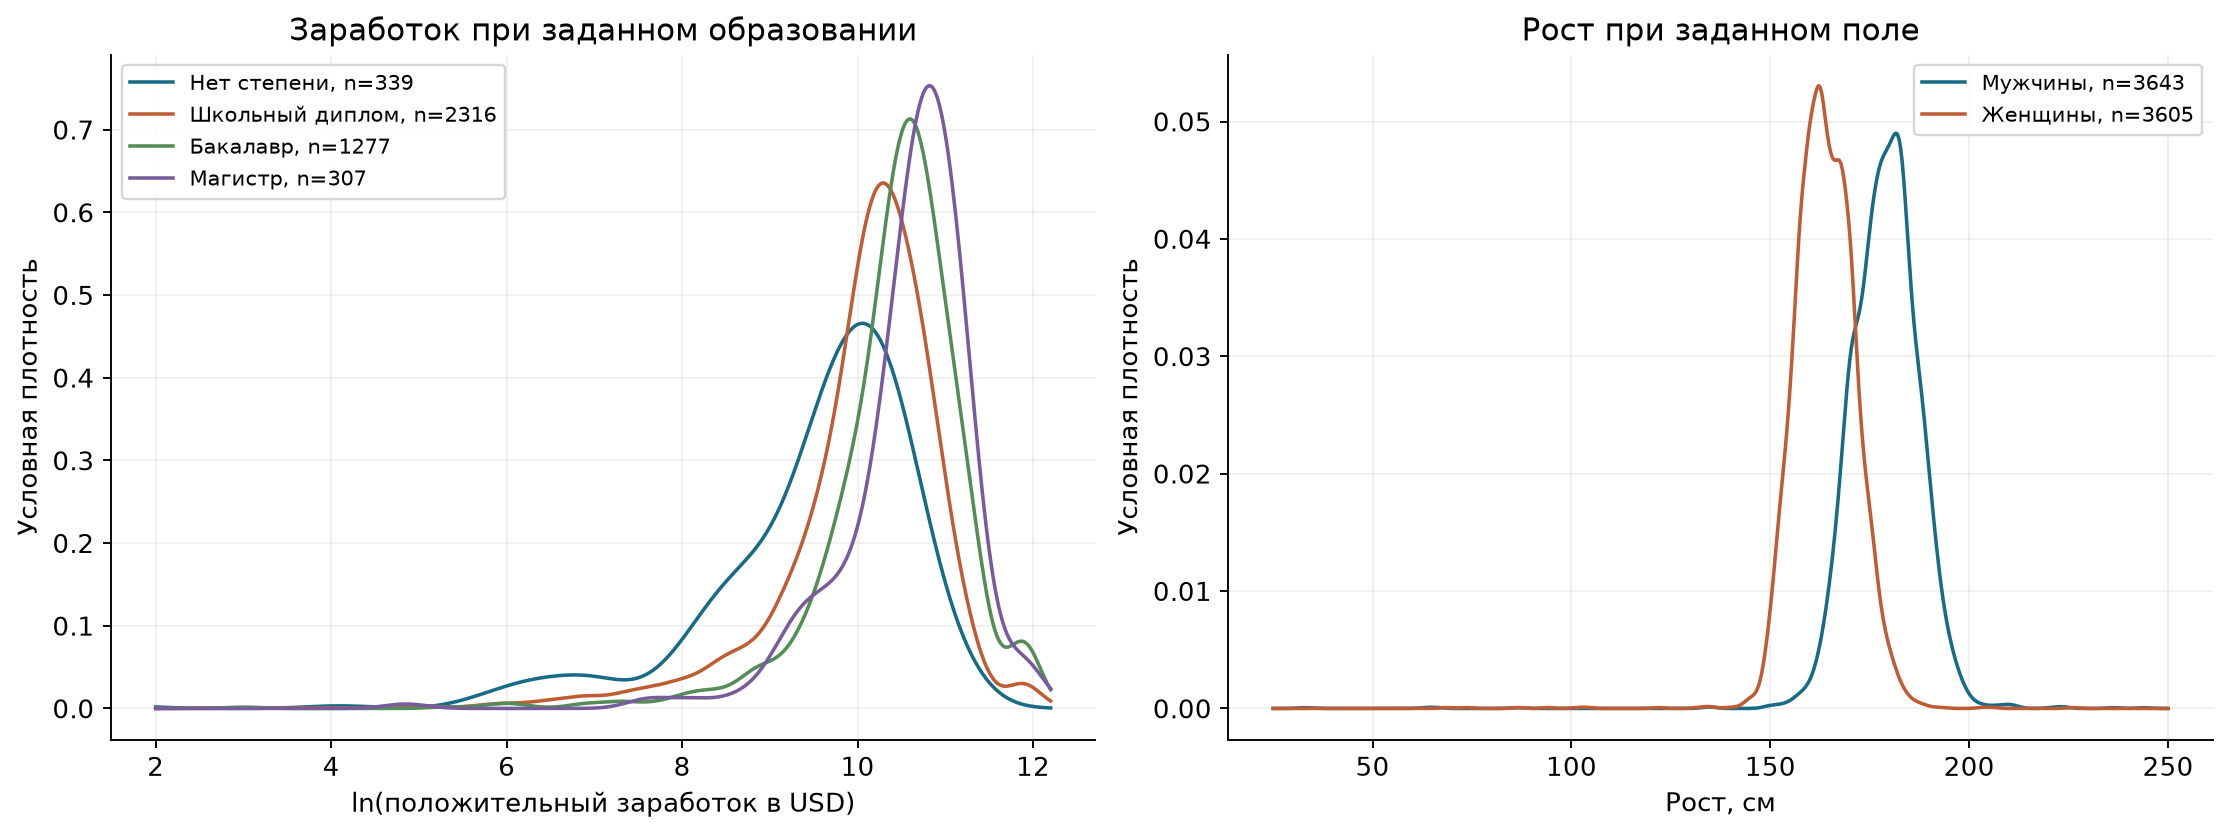

,education,n,mean,median,zero_fraction
0,Нет степени,655,10614.0550,600.0,0.4824
1,GED,843,14772.7485,9700.0,0.3808
2,Школьный диплом,2996,23913.1619,21650.0,0.2270
3,Associate,496,29866.3508,27000.0,0.1492
4,Бакалавр,1384,39715.7001,36000.0,0.0773
5,Магистр,329,44506.4711,44000.0,0.0669
6,PhD,14,56459.2143,49000.0,0.0714
7,Профессиональная степень,69,60303.7101,51000.0,0.1449


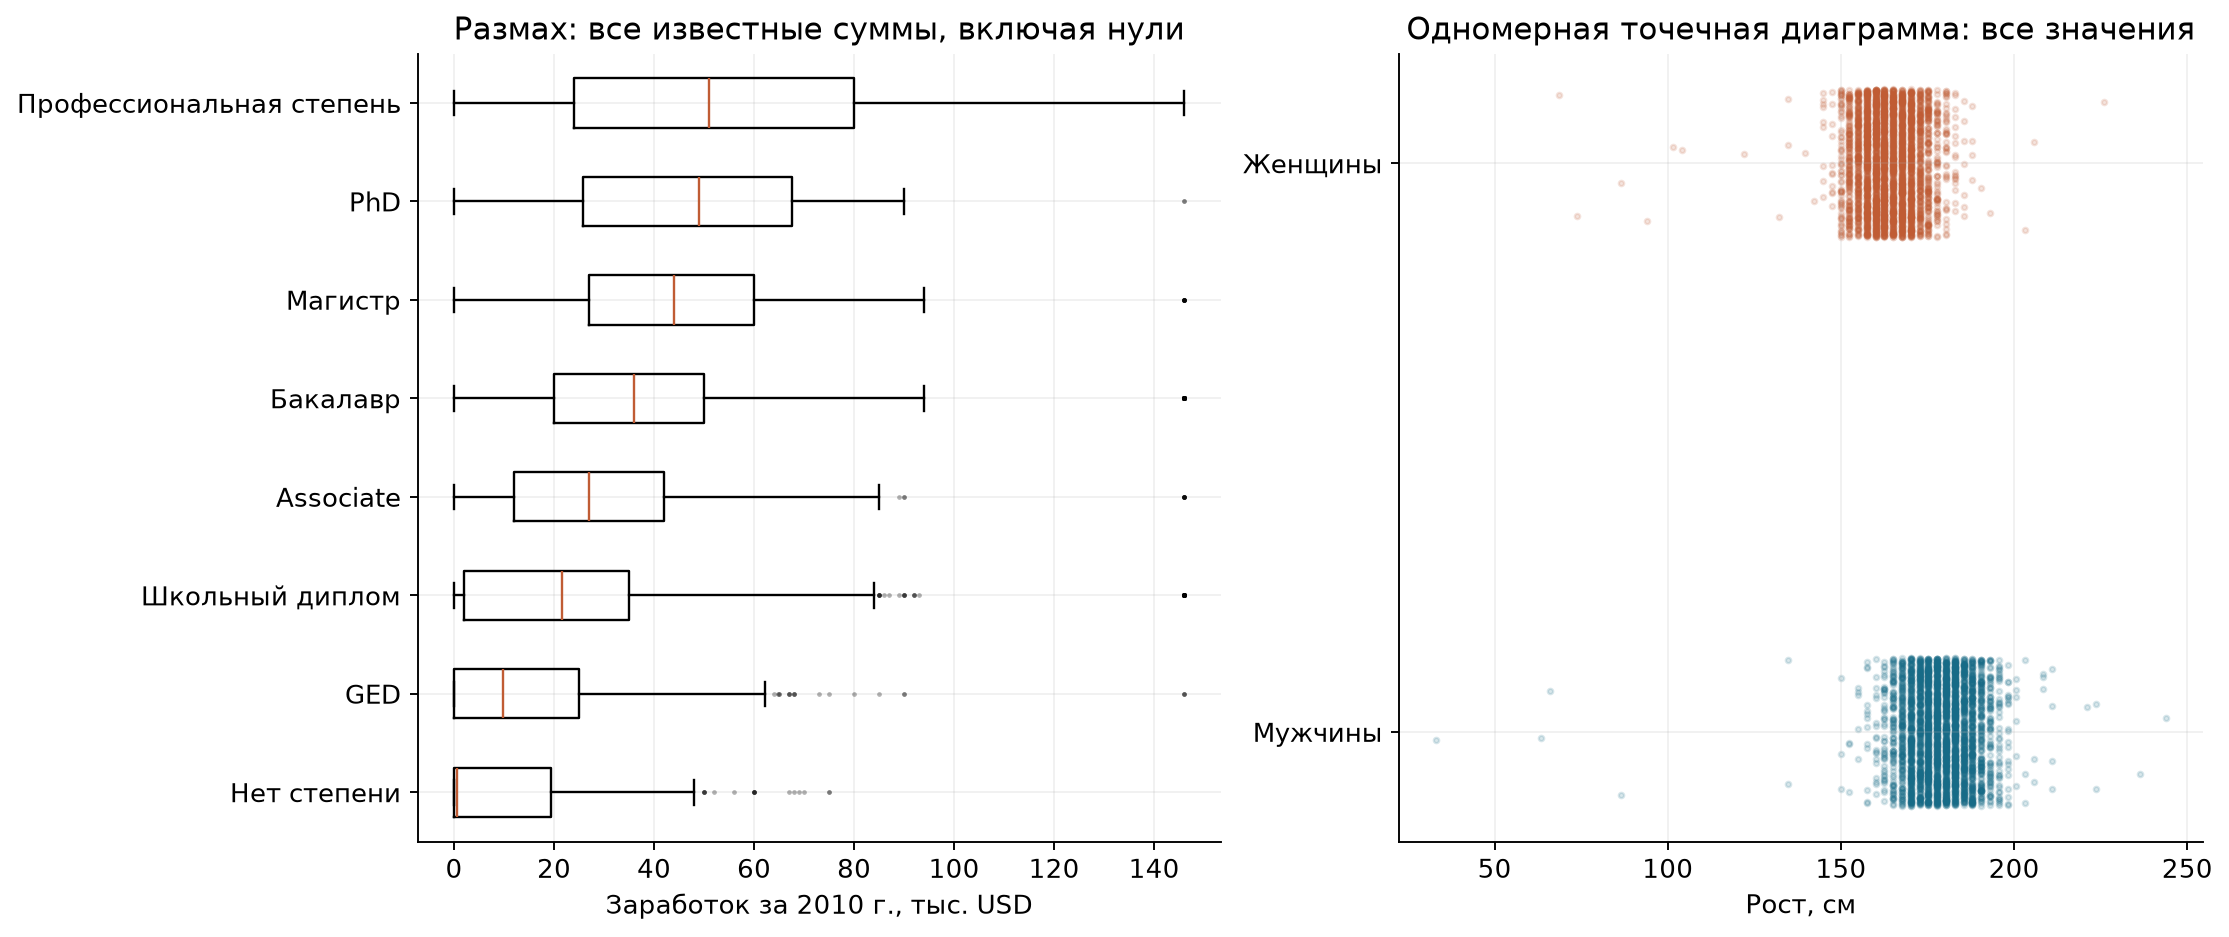

In [10]:
def conditional_analysis(nls):
    order=list(EDUCATION.values())
    grouped = nls[nls.wage_income_2010_usd.gt(0)].copy()
    fig,axes=plt.subplots(1,2,figsize=(13,4.8),layout='constrained')
    gx=np.linspace(2,12.2,500)
    group_stats=[]
    for code in [0,2,4,5]:
        a=np.log(grouped.loc[grouped.education_code.eq(code),'wage_income_2010_usd'])
        axes[0].plot(gx,stats.gaussian_kde(a)(gx), label=f'{EDUCATION[code]}, n={len(a)}')
    axes[0].set(xlabel='ln(положительный заработок в USD)',ylabel='Условная плотность',title='Заработок при заданном образовании')
    axes[0].legend(fontsize=9)
    sex_labels={'Male':'Мужчины','Female':'Женщины'}
    gh=np.linspace(25,250,600)
    for sex,label in sex_labels.items():
        a=nls.loc[nls.sex.eq(sex),'height_cm'].dropna()
        axes[1].plot(gh, stats.gaussian_kde(a)(gh), label=f'{label}, n={len(a)}')
    axes[1].set(title='Рост при заданном поле',xlabel='Рост, см',ylabel='Условная плотность')
    axes[1].legend(fontsize=9)
    figure(fig,'03_conditional_density')
    for label in order:
        x=nls.loc[nls.education.eq(label),'wage_income_2010_usd'].dropna()
        group_stats.append(dict(education=label,n=len(x),mean=x.mean(),median=x.median(),zero_fraction=x.eq(0).mean()))
    table(pd.DataFrame(group_stats),'wage_by_education')
    fig,axes=plt.subplots(1,2,figsize=(13,5.4),layout='constrained')
    samples=[nls.loc[nls.education.eq(label),'wage_income_2010_usd'].dropna()/1000 for label in order]
    axes[0].boxplot(samples,orientation='horizontal',tick_labels=order,showfliers=True,
                    flierprops=dict(marker='.',markersize=2,alpha=.3))
    axes[0].set(xlabel='Заработок за 2010 г., тыс. USD',title='Размах: все известные суммы, включая нули')
    rng=np.random.default_rng(SEED)
    for i,(sex,label) in enumerate(sex_labels.items()):
        a=nls.loc[nls.sex.eq(sex),'height_cm'].dropna()
        axes[1].scatter(a, i+rng.uniform(-.13,.13,len(a)),s=5,alpha=.16,rasterized=True)
    axes[1].set(yticks=[0,1],yticklabels=list(sex_labels.values()),xlabel='Рост, см',
                title='Одномерная точечная диаграмма: все значения')
    figure(fig,'04_box_strip')


conditional_analysis(nls)
show_figure("03_conditional_density")
display(TABLES["wage_by_education"])
show_figure("04_box_strip")


Распределения заработка различаются между группами образования. На диаграмме роста видны повторения из-за округления до дюймов и отдельные низкие значения. Точки за усами boxplot не обязательно являются ошибками.


## 4. Проверка наблюдений на выбросы

| Метод | Правило или настройка |
|---|---|
| Граббс | $G=\max|x_i-\bar{x}|/s$, нормальная модель, один предполагаемый экстремум |
| Диксон, r10 | Максимальный крайний зазор / размах; случайные 20 мужчин, 49 999 реплик для порога |
| Межквартильный размах | Границы $Q_1-1.5IQR$ и $Q_3+1.5IQR$ |
| Z-оценка | $|Z|>3$ |
| Isolation Forest | 300 деревьев, порог `auto` |
| LOF | 35 соседей, порог `auto` |

Граббс и Диксон предполагают независимые нормальные наблюдения. Дизайн опроса и округление ограничивают их применимость. IF и LOF получают одну выборку по пяти признакам после RobustScaler; их порог `auto` не является уровнем значимости.


In [11]:
from functools import lru_cache
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
def grubbs_test(x, alpha=0.05):
    """Двусторонний одиночный критерий Граббса, без повторного удаления.

    H0: iid N(mu, sigma²), H1: один экстремум. Критическая граница по NIST.
    position относится к входу после удаления NaN, а не к исходному person_id.
    """
    if not 0 < alpha < 1:
        raise ValueError("alpha должна лежать между 0 и 1")
    a = sample_1d(x)
    n = len(a)
    deviations = np.abs(a - a.mean()) / a.std(ddof=1)
    i = int(np.argmax(deviations))
    t = stats.t.ppf(1 - alpha / (2 * n), n - 2)
    critical = (n - 1) / np.sqrt(n) * np.sqrt(t * t / (n - 2 + t * t))
    return dict(n=n, statistic=float(deviations[i]), critical=float(critical),
                reject=bool(deviations[i] > critical), position=i, value=float(a[i]))


def dixon_statistic(x, axis=-1):
    """Двусторонний Q Диксона r10: max двух крайних зазоров / полный размах.

    Это фиксированная разновидность r10, не переключение r10/r11/r21/r22.
    Оба края учитываются при калибровке, односторонняя таблица не применяется.
    """
    a = np.sort(x, axis=axis)
    a = np.moveaxis(a, axis, -1)
    return np.maximum(a[..., 1] - a[..., 0], a[..., -1] - a[..., -2]) / (a[..., -1] - a[..., 0])


@lru_cache(maxsize=16)
def dixon_null(n, simulations=49999, seed=713):
    rng = np.random.default_rng(seed + n)
    return dixon_statistic(rng.normal(size=(simulations, n)))


def dixon_test(x, alpha=0.05, simulations=49999, seed=713):
    """Monte Carlo Q r10 для 3 <= n <= 30 при iid нормальном H0.

    p=(1+число T_sim>=T_obs)/(B+1); никогда не возвращает ложный p=0.
    """
    a = sample_1d(x)
    if len(a) > 30 or not 0 < alpha < 1 or simulations < 99:
        raise ValueError("Q: 3..30 наблюдений, 0<alpha<1, B>=99")
    null = dixon_null(len(a), simulations, seed)
    q = float(dixon_statistic(a))
    p = (1 + np.count_nonzero(null >= q)) / (len(null) + 1)
    ordered = np.sort(a)
    value = ordered[0] if ordered[1] - ordered[0] >= ordered[-1] - ordered[-2] else ordered[-1]
    return dict(n=len(a), statistic=q, critical=float(np.quantile(null, 1-alpha)),
                pvalue=p, mc_se=float(np.sqrt(p * (1-p) / (len(null)+1))),
                reject=bool(p < alpha), value=float(value), simulations=len(null))


In [12]:
def outlier_analysis(nls, employment):
    univariate=[]
    for c in FEATURES:
        x=nls[c].dropna()
        q1,q3=x.quantile([.25,.75]); iqr=q3-q1
        iqr_flag=(x<q1-1.5*iqr)|(x>q3+1.5*iqr)
        z=(x-x.mean())/x.std(ddof=1)
        for method,mask in [('IQR',iqr_flag),('Z>3',z.abs()>3)]:
            univariate.append(dict(feature=c,method=method,n=len(x),flagged=int(mask.sum()),
                                   fraction=float(mask.mean()),lower=q1-1.5*iqr if method=='IQR' else x.mean()-3*x.std(ddof=1),
                                   upper=q3+1.5*iqr if method=='IQR' else x.mean()+3*x.std(ddof=1)))
    uv=table(pd.DataFrame(univariate),'outliers_univariate')
    # Фиксированный срез без отбора по p-value. Для нормального H0 это только диагностика:
    # округление роста, дизайн опроса и возможные несколько ошибок нарушают предпосылки.
    male=nls.loc[nls.sex.eq('Male'),['person_id','height_cm']].dropna()
    g=grubbs_test(male.height_cm)
    g['person_id']=int(male.iloc[g['position']].person_id)
    g['scope']='Рост мужчин, все известные, iid-normal reference only'
    small=male.sample(n=20,random_state=SEED)
    table(small,'dixon_sample')
    d=dixon_test(small.height_cm)
    d['scope']='Фиксированная случайная подвыборка 20 мужчин, Q r10, ties/design caveat'
    formal=table(pd.DataFrame([dict(method='Grubbs',**g),dict(method='Dixon r10 MC',**d)]),'outliers_formal')
    # Complete-case анализ не требует заполнения до поиска аномалий.
    cols=['height_cm','weight_kg','sleep_hours_weeknight','household_size','wage_income_2010_usd']
    complete=nls[['person_id']+cols].dropna().copy()
    transformed=complete[cols].copy()
    transformed['wage_income_2010_usd']=np.log1p(transformed.wage_income_2010_usd)
    scaled=RobustScaler().fit_transform(transformed)
    model=IsolationForest(n_estimators=300,contamination='auto',random_state=SEED,n_jobs=1).fit(scaled)
    complete['if_score']=-model.score_samples(scaled)
    complete['if_flag']=model.predict(scaled)==-1
    lof=LocalOutlierFactor(n_neighbors=35,contamination='auto')
    complete['lof_flag']=lof.fit_predict(scaled)==-1
    complete['lof_score']=-lof.negative_outlier_factor_
    complete['both']=complete.if_flag&complete.lof_flag
    table(complete.sort_values('if_score',ascending=False),'outlier_records')
    common=int(complete.both.sum()); union=int((complete.if_flag|complete.lof_flag).sum())
    sensitivity=[]
    for k in [15,35,75]:
        detector=LocalOutlierFactor(n_neighbors=k,contamination='auto')
        flags=detector.fit_predict(scaled)==-1
        sensitivity.append(dict(method='LOF',setting=k,flagged=int(flags.sum())))
    # Заданная contamination задаёт бюджет пометок, а не уровень значимости.
    for q in [.01,.03,.05]:
        sensitivity.append(dict(method='IF score quantile',setting=q,
                                flagged=int((complete.if_score>complete.if_score.quantile(1-q)).sum())))
    table(pd.DataFrame(sensitivity),'outlier_sensitivity')
    fig,axes=plt.subplots(1,2,figsize=(12,4.8),layout='constrained')
    axes[0].scatter(complete.height_cm,complete.weight_kg,c=complete.if_score,cmap='viridis',s=9,alpha=.55)
    axes[0].set(xlabel='Рост, см',ylabel='Масса тела, кг',title='Isolation Forest: цвет = оценка необычности')
    axes[1].scatter(complete.if_score,complete.lof_score,s=9,alpha=.4)
    axes[1].axhline(1.5,color=COLORS[1],ls='--',label='LOF auto: 1.5')
    axes[1].axvline(.5,color=COLORS[0],ls='--',label='IF auto: 0.5')
    axes[1].set(yscale='log',xlabel='Isolation Forest score',ylabel='LOF score (лог. шкала)',title='Детекторы находят разные типы необычности')
    axes[1].legend(fontsize=9)
    figure(fig,'05_outliers')
    # Временные флаги: на изменениях, а не на общей высоте уровня.
    changes=employment.diff()
    rows=[]
    for c in employment:
        x=changes[c].dropna(); q1,q3=x.quantile([.25,.75]); iqr=q3-q1
        mask=(x<q1-1.5*iqr)|(x>q3+1.5*iqr)
        for date in x.index[mask]:
            rows.append(dict(date=date,series=c,change_pp=x.loc[date],rule='IQR месячных изменений; описательный флаг'))
    table(pd.DataFrame(rows),'time_outliers')
    return dict(univariate=uv,formal=formal,complete_n=len(complete),if_n=int(complete.if_flag.sum()),
                lof_n=int(complete.lof_flag.sum()),both_n=common,jaccard=common/union if union else 1.)

outliers = outlier_analysis(nls, employment)
display(outliers["univariate"])
display(outliers["formal"])
display(TABLES["dixon_sample"])


,feature,method,n,flagged,fraction,lower,upper
0,age,IQR,7423,0,0.0000,25.0000,33.0000
1,age,Z>3,7423,0,0.0000,24.3557,33.1292
2,highest_grade_completed,IQR,7337,2,0.0003,6.0000,22.0000
3,highest_grade_completed,Z>3,7337,0,0.0000,4.7323,22.2684
4,wage_income_2010_usd,IQR,6818,120,0.0176,-54000.0000,96400.0000
5,wage_income_2010_usd,Z>3,6818,120,0.0176,-53735.7981,106870.3593
6,family_income_2010_usd,IQR,6528,292,0.0447,-58000.0000,166000.0000
7,family_income_2010_usd,Z>3,6528,173,0.0265,-111383.4738,237703.6050
8,job01_hours_per_week,IQR,6128,1004,0.1638,20.0000,52.0000
9,job01_hours_per_week,Z>3,6128,55,0.0090,-3.0381,77.1970


,method,n,statistic,critical,reject,position,value,person_id,scope,pvalue,mc_se,simulations
0,Grubbs,3643,15.9987,4.3429,True,137.0,33.02,349.0,"Рост мужчин, все известные, iid-normal reference only",NaN,NaN,NaN
1,Dixon r10 MC,20,0.2000,0.3437,False,NaN,165.10,NaN,"Фиксированная случайная подвыборка 20 мужчин, Q r10, ties/design caveat",0.3543,0.0021,49999.0


,person_id,height_cm
4832,5953,170.18
1945,2469,177.80
7143,8684,165.10
273,350,175.26
1431,1820,182.88
3603,4492,187.96
2533,3197,175.26
1210,1535,172.72
1549,1966,175.26
1506,1915,175.26


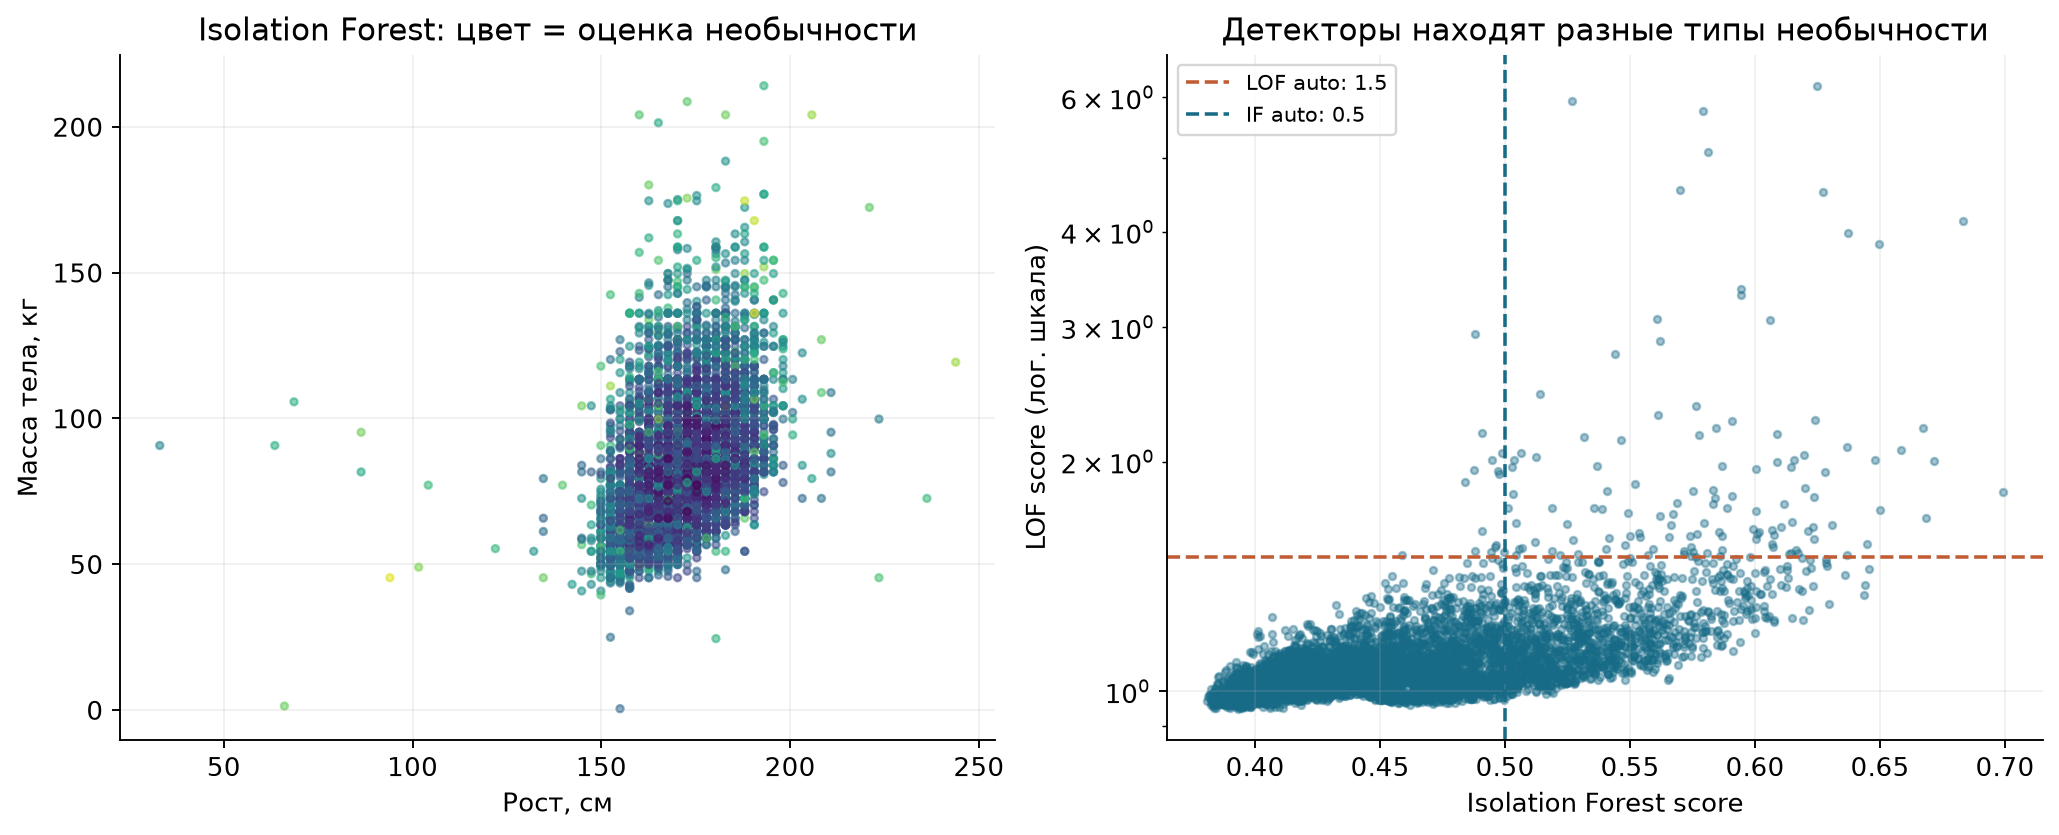

Полных строк: **6555**. IF пометил 1363, LOF — 136, оба — 121. Jaccard пометок: 0.088. Это согласованность алгоритмов.

,method,setting,flagged
0,LOF,15.00,134
1,LOF,35.00,136
2,LOF,75.00,174
3,IF score quantile,0.01,66
4,IF score quantile,0.03,197
5,IF score quantile,0.05,328


,person_id,height_cm,weight_kg,sleep_hours_weeknight,household_size,wage_income_2010_usd,if_score,if_flag,lof_flag,lof_score,both
6269,7661,190.50,136.0777,3.0,8.0,0.0,0.6992,True,True,1.8273,True
4297,5328,93.98,45.3592,12.0,2.0,0.0,0.6833,True,True,4.1300,True
5372,6610,187.96,113.3981,9.0,11.0,0.0,0.6716,True,True,2.0017,True
3351,4192,187.96,174.6331,3.0,2.0,0.0,0.6682,True,True,1.6886,True
5689,6990,190.50,167.8292,10.0,7.0,19000.0,0.6671,True,True,2.2120,True
5813,7139,160.02,49.8952,4.0,11.0,0.0,0.6584,True,True,2.0686,True
2696,3405,152.40,111.1301,6.0,11.0,0.0,0.6498,True,True,1.7264,True
855,1094,243.84,119.2948,10.0,4.0,1000.0,0.6496,True,True,3.8549,True


,date,series,change_pp,rule
11,2004-06-01,employment_men,3.0151,IQR месячных изменений; описательный флаг
33,2004-06-01,employment_balanced,1.9927,IQR месячных изменений; описательный флаг
13,2005-06-01,employment_men,1.9708,IQR месячных изменений; описательный флаг
1,2004-06-01,employment_all,1.8862,IQR месячных изменений; описательный флаг
23,2004-11-01,employment_women,1.7857,IQR месячных изменений; описательный флаг
25,2005-10-01,employment_women,1.7775,IQR месячных изменений; описательный флаг
36,2005-10-01,employment_balanced,1.7245,IQR месячных изменений; описательный флаг
35,2004-11-01,employment_balanced,1.6095,IQR месячных изменений; описательный флаг


In [13]:
show_figure("05_outliers")
display(Markdown(f"Полных строк: **{outliers['complete_n']}**. IF пометил "
    f"{outliers['if_n']}, LOF — {outliers['lof_n']}, оба — {outliers['both_n']}. "
    f"Jaccard пометок: {outliers['jaccard']:.3f}. Это согласованность алгоритмов."))
display(TABLES["outlier_sensitivity"])
display(TABLES["outlier_records"].head(8))
display(TABLES["time_outliers"].sort_values("change_pp", ascending=False).head(8))


Методы выделяют разные наблюдения: крайнее значение отдельного признака или редкую комбинацию нескольких. Записи не удаляются. Результат Диксона относится только к выбранным 20 людям, а изменение занятости может быть реальным событием.


## 5. Заполнение пропусков и оценка качества

### 5.1. Табличные данные

Скрываем известные значения, чтобы сравнить восстановление с исходными данными. Кластеры опроса разделены на train/test примерно 70/30. Scaler и методы заполнения обучаются только на train.

Сравниваем среднее, медиану, KNN и IterativeImputer на одинаковых пяти масках: случайные пропуски 10% и 30% (MCAR), а также 30% с вероятностью, зависящей от образования (MAR-like).

$$MAE=\frac{1}{m}\sum|\hat y-y|,\qquad RMSE=\sqrt{\frac{1}{m}\sum(\hat y-y)^2}.$$

Ошибки считаются только в скрытых ячейках test, отдельно для каждого признака в его единицах.


In [14]:
import warnings
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
def mask_observed(frame, fraction, rng):
    """MCAR: скрыть точную долю известных значений отдельно в каждом столбце."""
    if not 0 < fraction < 1:
        raise ValueError('Доля должна лежать между 0 и 1')
    mask = np.zeros(frame.shape, dtype=bool)
    for j in range(frame.shape[1]):
        eligible = np.flatnonzero(frame.iloc[:, j].notna().to_numpy())
        if len(eligible) < 2:
            raise ValueError('Недостаточно известных значений')
        k = min(len(eligible)-1, max(1, round(fraction*len(eligible))))
        mask[rng.choice(eligible, k, replace=False), j] = True
    return frame.mask(mask), mask


def imputation_metrics(truth, prediction, mask):
    """Метрики ТОЛЬКО по искусственно скрытым известным ячейкам."""
    truth, prediction, mask = np.asarray(truth), np.asarray(prediction), np.asarray(mask)
    if truth.shape != prediction.shape or mask.shape != truth.shape or not mask.any():
        raise ValueError('Неверные формы или пустая маска')
    actual = truth[mask]
    predicted = prediction[mask]
    if not np.isfinite(actual).all() or not np.isfinite(predicted).all():
        raise ValueError('Истина/предсказание в оцениваемых ячейках не определены')
    error = predicted-actual
    return dict(mae=float(np.abs(error).mean()), rmse=float(np.sqrt(np.mean(error**2))),
                bias=float(error.mean()), n_hidden=int(mask.sum()))


Размеры train/test: 5239 2184


,scenario,feature,method,mae,mae_sd,rmse,rmse_sd,bias,n_hidden,nrmse
48,MCAR30,family_income_2010_usd,Iterative,37060.0401,1634.9725,55796.0565,775.7065,1137.1065,590,1.0053
49,MCAR30,family_income_2010_usd,KNN(7),42645.8648,1838.0544,65781.6986,2694.1323,-2758.6194,590,1.1854
50,MCAR30,family_income_2010_usd,Mean,41326.1647,489.0483,61159.5412,1140.0773,-1253.8280,590,1.1020
51,MCAR30,family_income_2010_usd,Median,39691.3488,1136.9616,62751.3877,1474.6540,-14185.8763,590,1.1308
52,MCAR30,height_cm,Iterative,6.6327,0.5744,8.7531,0.9531,-0.4805,640,0.4923
53,MCAR30,height_cm,KNN(7),7.2357,0.4338,9.7077,0.7110,-0.2738,640,0.5460
54,MCAR30,height_cm,Mean,9.1156,0.0945,11.0692,0.2368,-0.3286,640,0.6226
55,MCAR30,height_cm,Median,9.0551,0.0910,11.1471,0.2332,-1.3589,640,0.6269
56,MCAR30,job01_hours_per_week,Iterative,10.1177,0.7851,14.5885,0.4222,-0.4776,543,2.0413
57,MCAR30,job01_hours_per_week,KNN(7),10.6077,0.5161,15.4144,0.9040,-0.3034,543,2.1555


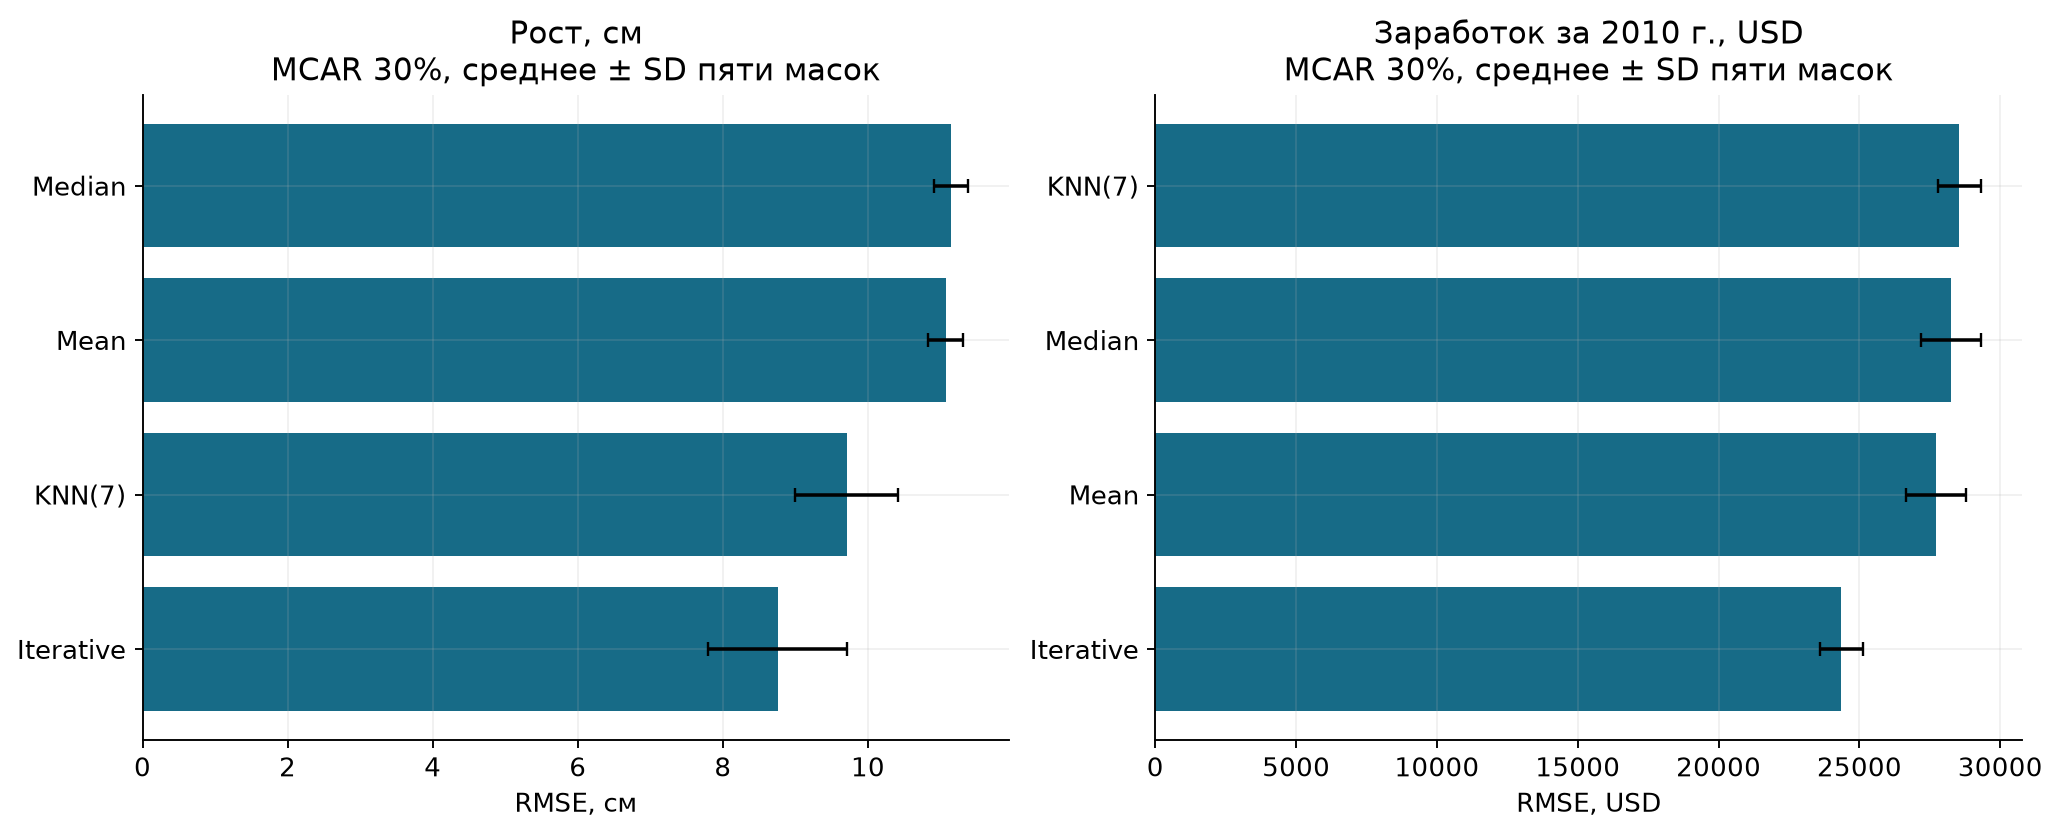

In [15]:
def tabular_imputation(nls, repeats=5):
    """Оценка на отложенных PSU. Скалер/импутер не видят test при fit.

    MCAR 10/30% и MAR-like 30% (маска зависит от наблюдаемой категории
    образования). Истинные значения остаются исключительно у оценщика.
    Пропуски входа сохраняются, никогда не служат целями метрик.
    """
    targets=['height_cm','weight_kg','sleep_hours_weeknight','wage_income_2010_usd',
             'family_income_2010_usd','job01_hours_per_week']
    aux=['age','highest_grade_completed','grade_ungraded','sex_code','household_size']
    cols=targets+aux
    groups=nls.variance_stratum.astype(str)+'/'+nls.variance_psu.astype(str)
    split=GroupShuffleSplit(n_splits=1,test_size=.3,random_state=SEED)
    train_idx,test_idx=next(split.split(nls,groups=groups))
    train=nls.iloc[train_idx][cols].copy(); test=nls.iloc[test_idx][cols].copy()
    assert set(groups.iloc[train_idx]).isdisjoint(groups.iloc[test_idx])
    table(pd.DataFrame({'person_id':nls.person_id,'split':np.where(nls.index.isin(train_idx),'train','test'),
                        'design_cluster':groups}),'imputation_split')
    rows=[]; warning_log=[]
    for scenario,fraction in [('MCAR10',.1),('MCAR30',.3),('MAR30',.3)]:
        for rep in range(repeats):
            rng=np.random.default_rng(SEED+rep+int(fraction*1000)+(10000 if scenario.startswith('MAR') else 0))
            def corrupt(frame):
                if scenario.startswith('MCAR'):
                    hidden,mask=mask_observed(frame[targets],fraction,rng)
                else:
                    mask=np.zeros((len(frame),len(targets)),dtype=bool)
                    weights=np.where(nls.loc[frame.index,'education_code'].fillna(-1).ge(4),3.,1.)
                    for j,c in enumerate(targets):
                        eligible=np.flatnonzero(frame[c].notna().to_numpy())
                        p=weights[eligible]; p=p/p.sum()
                        chosen=rng.choice(eligible,round(fraction*len(eligible)),replace=False,p=p)
                        mask[chosen,j]=True
                    hidden=frame[targets].mask(mask)
                result=frame.copy(); result[targets]=hidden
                return result,mask
            train_hidden,_=corrupt(train)
            test_hidden,mask=corrupt(test)
            scaler=StandardScaler().fit(train_hidden)
            a=scaler.transform(train_hidden); b=scaler.transform(test_hidden)
            factories={
                'Mean':lambda:SimpleImputer(strategy='mean'),
                'Median':lambda:SimpleImputer(strategy='median'),
                'KNN(7)':lambda:KNNImputer(n_neighbors=7,weights='distance'),
                'Iterative':lambda:IterativeImputer(max_iter=100,tol=.005,random_state=SEED+rep,
                                                    initial_strategy='median',sample_posterior=False),
            }
            for name,factory in factories.items():
                with warnings.catch_warnings(record=True) as caught:
                    warnings.simplefilter('always')
                    model=factory().fit(a)
                    pred=scaler.inverse_transform(model.transform(b))[:,:len(targets)]
                for warning in caught:
                    warning_log.append(dict(scenario=scenario,repeat=rep,method=name,warning=str(warning.message)))
                # Все выбранные целевые величины неотрицательны. Это ограничение
                # области определения; верхний хвост не обрезается по результатам.
                pred=np.maximum(pred,0)
                for j,c in enumerate(targets):
                    scores=imputation_metrics(test[c].to_numpy(),pred[:,j],mask[:,j])
                    scale=train_hidden[c].quantile(.75)-train_hidden[c].quantile(.25)
                    rows.append(dict(scenario=scenario,repeat=rep,method=name,feature=c,
                                     normalized_rmse=scores['rmse']/scale if scale>0 else np.nan,**scores))
    results=table(pd.DataFrame(rows),'imputation_tabular_runs')
    summary=results.groupby(['scenario','feature','method']).agg(
        mae=('mae','mean'),mae_sd=('mae','std'),rmse=('rmse','mean'),rmse_sd=('rmse','std'),
        bias=('bias','mean'),n_hidden=('n_hidden','first'),nrmse=('normalized_rmse','mean')).reset_index()
    table(summary,'imputation_tabular_summary')
    table(pd.DataFrame(warning_log,columns=['scenario','repeat','method','warning']),'imputation_warnings')
    fig,axes=plt.subplots(1,2,figsize=(12,4.8),layout='constrained')
    for ax,c in zip(axes,['height_cm','wage_income_2010_usd']):
        s=summary[(summary.scenario=='MCAR30')&summary.feature.eq(c)].sort_values('rmse')
        ax.barh(s.method,s.rmse,xerr=s.rmse_sd,color=COLORS[0],capsize=3)
        ax.set(xlabel=f'RMSE, {"см" if c=="height_cm" else "USD"}',title=FEATURES[c]+'\nMCAR 30%, среднее ± SD пяти масок')
    figure(fig,'06_imputation_tabular')
    return dict(summary=summary,runs=results,train_n=len(train),test_n=len(test),warnings=len(warning_log))

tabular = tabular_imputation(nls, repeats=5)
print("Размеры train/test:", tabular["train_n"], tabular["test_n"])
display(tabular["summary"].query("scenario == 'MCAR30'"))
show_figure("06_imputation_tabular")


In [16]:
# Лучший из заранее заданных методов в этой оценке, отдельно для каждой цели.
s = tabular["summary"].query("scenario == 'MCAR30'")
best = s.loc[s.groupby("feature")["rmse"].idxmin(), ["feature", "method", "rmse", "rmse_sd"]]
display(best)
display(tabular["summary"].query("feature == 'wage_income_2010_usd'")[
    ["scenario", "method", "mae", "rmse", "bias"]])
warnings_table = TABLES["imputation_warnings"]
display(warnings_table)
print("Предупреждений алгоритмов:", len(warnings_table))


,feature,method,rmse,rmse_sd
48,family_income_2010_usd,Iterative,55796.0565,775.7065
52,height_cm,Iterative,8.7531,0.9531
58,job01_hours_per_week,Mean,13.9163,0.6407
62,sleep_hours_weeknight,Mean,1.3639,0.0278
64,wage_income_2010_usd,Iterative,24361.9706,766.1724
70,weight_kg,Mean,21.6478,0.7877


,scenario,method,mae,rmse,bias
16,MAR30,Iterative,17717.9429,26167.2158,-791.3589
17,MAR30,KNN(7),22237.5967,32005.6983,-2390.5625
18,MAR30,Mean,22042.0761,31488.4732,-7283.4703
19,MAR30,Median,22743.3947,32774.1804,-11646.7125
40,MCAR10,Iterative,14882.8207,21962.3748,597.1974
41,MCAR10,KNN(7),16430.2004,23722.1714,-1875.5952
42,MCAR10,Mean,19963.4418,27540.5620,-576.8236
43,MCAR10,Median,19845.6350,27904.4696,-4548.4390
64,MCAR30,Iterative,16888.9818,24361.9706,1186.9672
65,MCAR30,KNN(7),19758.0833,28547.9604,-2192.8418


,scenario,repeat,method,warning


Предупреждений алгоритмов: 0


Для роста дополнительные признаки помогают уменьшить ошибку; для сна сложная модель не обязательно лучше. Разброс между масками относится к одному разбиению train/test. Настройки на test не подбирались. Эти результаты не гарантируют такого же качества на настоящих неответах.

### 5.2. Временные ряды

Сравним медиану, перенос предыдущего значения и интерполяцию по времени. Скрываем случайные 10% месяцев или блок из шести месяцев, по 10 повторов. Отдельно проверяем март–август 2020 года. Ошибка измеряется в процентных пунктах доли работающих.


,scenario,series,method,mae,rmse,rmse_sd
0,block_6months,employment_all,Forward fill,0.7271,0.8072,0.6013
1,block_6months,employment_all,Linear (time),0.3854,0.4581,0.2048
2,block_6months,employment_all,Median,1.8321,1.9001,1.0076
3,block_6months,employment_balanced,Forward fill,0.8223,0.9184,0.6922
4,block_6months,employment_balanced,Linear (time),0.4207,0.4994,0.2216
5,block_6months,employment_balanced,Median,1.7203,1.8082,1.0190
6,block_6months,employment_men,Forward fill,0.7609,0.8732,0.9959
7,block_6months,employment_men,Linear (time),0.4089,0.4780,0.3275
8,block_6months,employment_men,Median,2.2990,2.3723,1.4298
9,block_6months,employment_women,Forward fill,0.9501,1.0447,0.5405


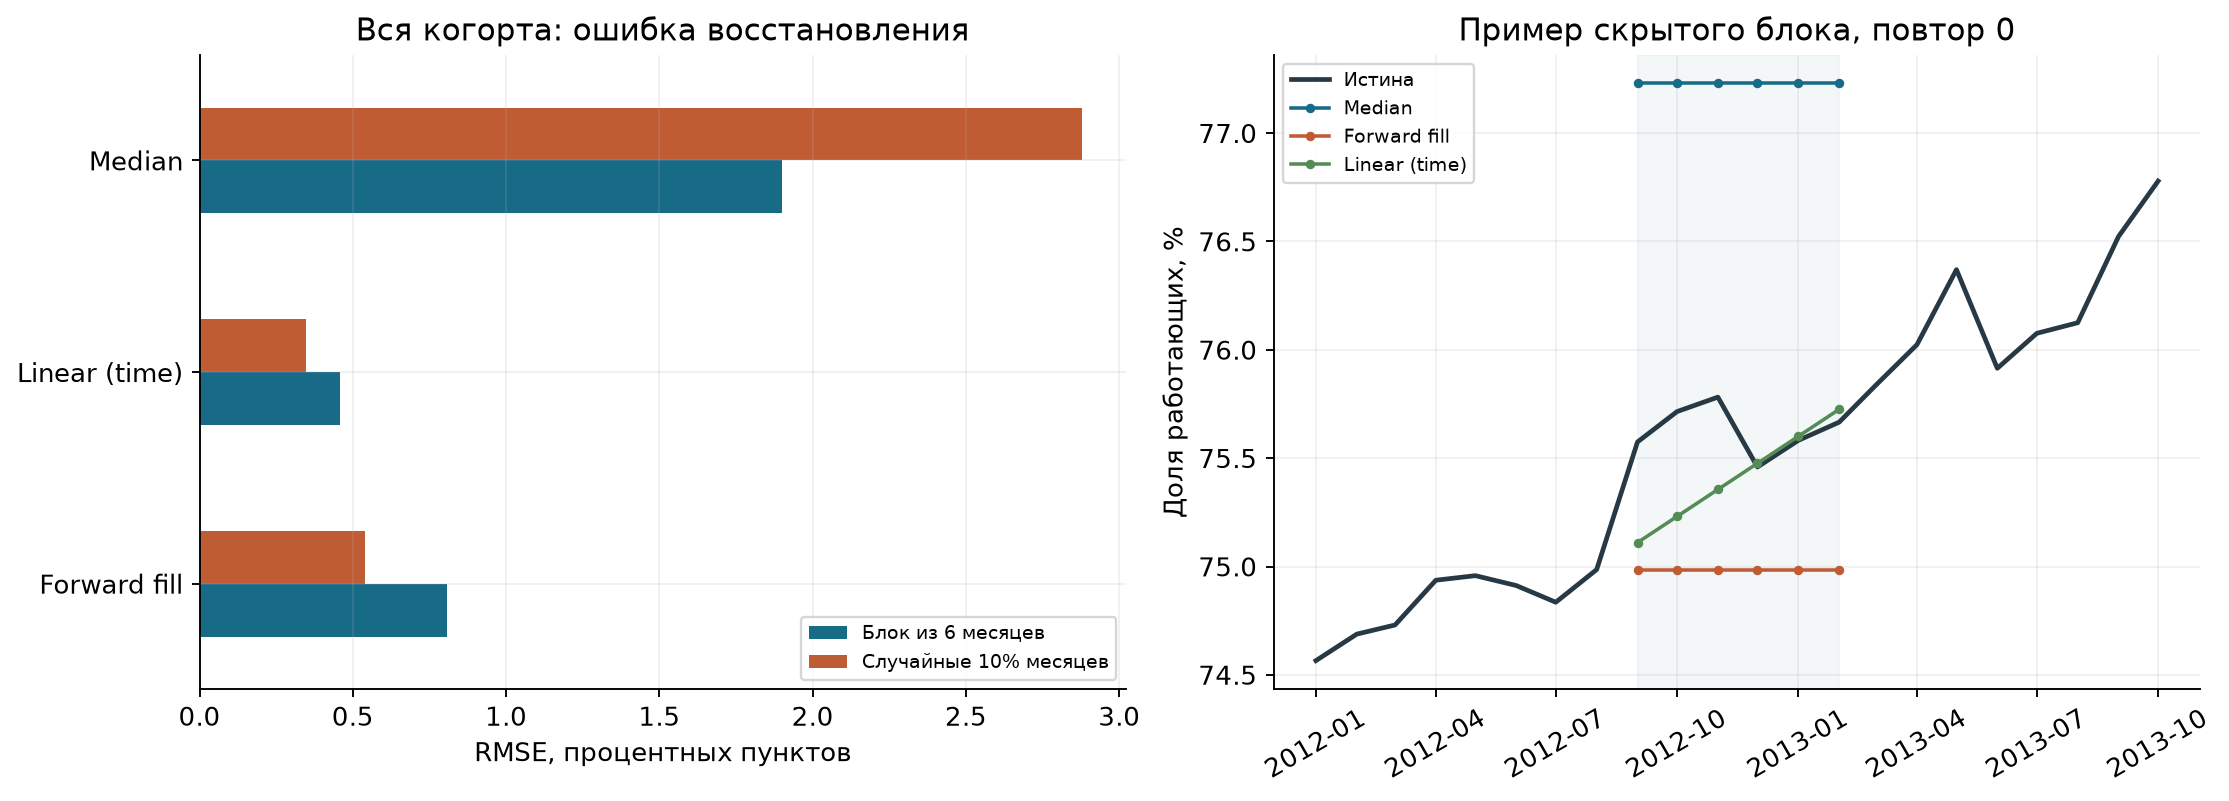

,method,series,mae,rmse,bias,n_hidden
0,Median,employment_all,0.9466,1.1004,0.2974,6
1,Median,employment_men,0.7031,0.8804,-0.3654,6
2,Median,employment_women,1.1272,1.3989,0.1716,6
3,Median,employment_balanced,1.1944,1.2694,0.6068,6
4,Forward fill,employment_all,3.6546,3.8051,3.6546,6
5,Forward fill,employment_men,2.3877,2.5185,2.3877,6
6,Forward fill,employment_women,4.8471,5.0420,4.8471,6
7,Forward fill,employment_balanced,3.9791,4.1323,3.9791,6
8,Linear (time),employment_all,2.3028,2.5107,2.3028,6
9,Linear (time),employment_men,1.6895,1.8929,1.6895,6


In [17]:
def time_imputation(employment, repeats=10):
    """Восстановление исторических внутренних пробелов, НЕ прогноз будущего.

    Линейная интерполяция пользуется обеими границами. Ошибки оцениваем
    только на искусственно скрытых известных значениях. Маски общие у всех методов/рядов. Случайные точки
    и непрерывный блок длины 6 моделируют разные виды потерь.
    """
    rows=[]; examples={}
    values=employment.copy()
    known=values.notna().all(axis=1).to_numpy()
    candidates=np.flatnonzero(known&np.roll(known,1)&np.roll(known,-1))
    candidates=candidates[(candidates>0)&(candidates<len(values)-1)]
    starts=[s for s in range(1,len(values)-6) if known[s-1:s+7].all()]
    for scenario in ['points_10pct','block_6months']:
        for rep in range(repeats):
            rng=np.random.default_rng(SEED+900+rep)
            if scenario=='points_10pct':
                idx=rng.choice(candidates,round(.1*known.sum()),replace=False)
            else:
                start=int(rng.choice(starts)); idx=np.arange(start,start+6)
            mask=np.zeros(values.shape,dtype=bool);mask[idx,:]=True
            hidden=values.mask(mask)
            predictions={
                'Median':hidden.fillna(hidden.median()),
                'Forward fill':hidden.ffill(),
                'Linear (time)':hidden.interpolate(method='time',limit_area='inside'),
            }
            for name,pred in predictions.items():
                for c in values:
                    scores=imputation_metrics(values[c].to_numpy(),pred[c].to_numpy(),mask[:,values.columns.get_loc(c)])
                    rows.append(dict(scenario=scenario,repeat=rep,method=name,series=c,**scores))
            if scenario=='block_6months' and rep==0:
                examples=dict(idx=idx,predictions=predictions)
    runs=table(pd.DataFrame(rows),'imputation_time_runs')
    summary=table(runs.groupby(['scenario','series','method']).agg(
        mae=('mae','mean'),rmse=('rmse','mean'),rmse_sd=('rmse','std')).reset_index(),'imputation_time_summary')
    # Отдельное стресс-испытание на отрезке 2020: не смешиваем с рандомным средним.
    crisis_mask=np.zeros(values.shape,dtype=bool)
    crisis_mask[(values.index>='2020-03-01')&(values.index<='2020-08-01'),:]=True
    crisis_hidden=values.mask(crisis_mask)
    crisis=[]
    for name,pred in [('Median',crisis_hidden.fillna(crisis_hidden.median())),
                      ('Forward fill',crisis_hidden.ffill()),('Linear (time)',crisis_hidden.interpolate(method='time'))]:
        for j,c in enumerate(values):
            crisis.append(dict(method=name,series=c,**imputation_metrics(values[c],pred[c],crisis_mask[:,j])))
    table(pd.DataFrame(crisis),'imputation_time_crisis')
    fig,axes=plt.subplots(1,2,figsize=(13,4.6),layout='constrained')
    s=summary[summary.series.eq('employment_all')]
    pivot=s.pivot(index='method',columns='scenario',values='rmse')
    pivot.plot.barh(ax=axes[0],color=COLORS[:2])
    axes[0].set(title='Вся когорта: ошибка восстановления',xlabel='RMSE, процентных пунктов',ylabel='')
    axes[0].legend(['Блок из 6 месяцев','Случайные 10% месяцев'],fontsize=8)
    idx=examples['idx']; c='employment_all'; region=values.iloc[max(0,min(idx)-8):max(idx)+9]
    axes[1].plot(region.index,region[c],color='#273944',lw=2,label='Истина')
    for name,pred in examples['predictions'].items():
        axes[1].plot(values.index[idx],pred.iloc[idx][c],marker='o',ms=3,label=name)
    axes[1].axvspan(values.index[min(idx)],values.index[max(idx)],color='#DAE5E8',alpha=.3)
    axes[1].set(title='Пример скрытого блока, повтор 0',ylabel='Доля работающих, %')
    axes[1].legend(fontsize=8)
    axes[1].tick_params(axis='x',rotation=30)
    figure(fig,'07_imputation_time')
    return dict(summary=summary,crisis=pd.DataFrame(crisis))

temporal = time_imputation(employment, repeats=10)
display(temporal["summary"])
show_figure("07_imputation_time")
display(temporal["crisis"])


Интерполяция использует известные значения с обеих сторон пробела. Это восстановление истории, а не прогноз. Для каждого метода сравниваем средний RMSE случайных масок с отдельным блоком марта–августа 2020 года: длинный пробел может скрывать резкие изменения.

## 6. Q–Q графики, метод огибающих и проверка нормальности

Проверяем гипотезу нормальности при α = 0.05 на вложенных подвыборках разных объёмов и на полных данных.

| Критерий | Особенность |
|---|---|
| Колмогорова–Смирнова в модификации Лиллиефорса | Учитывает оценку параметров; табличные p ограничены 0.001 и 0.990 |
| Шапиро–Уилка | p вычисляется при n ≤ 5000 |
| Шапиро–Франсия | Приближение Ройстона, 5 ≤ n ≤ 5000 |
| Андерсона–Дарлинга | Монте-Карло с переоценкой параметров |
| Крамера–фон Мизеса | Монте-Карло с переоценкой параметров |

Для двух последних критериев 4 999 реплик, минимальное p = 0.0002. Точечная 95%-я огибающая относится к отдельному рангу, одновременная — ко всей Q–Q кривой. Параметры нормального закона заново оцениваются в каждой реплике.

Предпосылки независимости для этих данных выполнены не строго: p-value служат ориентиром относительно нормальной iid-модели.


In [18]:
from statsmodels.stats.diagnostic import lilliefors
from statsmodels.stats.multitest import multipletests
def shapiro_francia(x):
    """W'=corr²(x_(i), Phi^-1((i-3/8)/(n+1/4))).

    Аппроксимация Royston (1993), как в R nortest::sf.test, 5 <= n <= 5000.
    Реализация формул, источник указан в конце ноутбука. Совпадения значений (ties)
    нарушают непрерывное H0 и не исправляются добавлением случайного шума.
    """
    a = np.sort(sample_1d(x, minimum=5))
    n = len(a)
    if n > 5000:
        raise ValueError("Аппроксимация Шапиро–Франсия допускает n<=5000")
    q = stats.norm.ppf((np.arange(1, n+1)-3/8) / (n+1/4))
    w = float(np.clip(np.corrcoef(a, q)[0, 1] ** 2, 0, 1))
    u = np.log(n)
    v = np.log(u)
    mu = -1.2725 + 1.0521 * (v-u)
    sigma = 1.0308 - 0.26758 * (v+2/u)
    z = (np.log(max(1-w, np.finfo(float).tiny)) - mu) / sigma
    return w, float(stats.norm.sf(z))


def cvm_fitted_statistic(x, axis=-1):
    """W² относительно нормального закона с заново оценёнными mu и sigma.

    Используется ddof=1, как scipy.stats.goodness_of_fit для normal.
    """
    a = np.asarray(x, dtype=float)
    z = (a - a.mean(axis=axis, keepdims=True)) / a.std(axis=axis, ddof=1, keepdims=True)
    z = np.moveaxis(np.sort(z, axis=axis), axis, -1)
    n = z.shape[-1]
    u = stats.norm.cdf(z)
    return 1/(12*n) + ((u - (2*np.arange(1,n+1)-1)/(2*n))**2).sum(axis=-1)


def ad_fitted_statistic(x, axis=-1):
    """Anderson–Darling через logcdf/logsf, без log(0) в далёком хвосте."""
    a = np.asarray(x, dtype=float)
    z = (a-a.mean(axis=axis, keepdims=True))/a.std(axis=axis, ddof=1, keepdims=True)
    z = np.moveaxis(np.sort(z, axis=axis), axis, -1)
    n = z.shape[-1]
    return -n - np.sum((2*np.arange(1,n+1)-1) *
                       (stats.norm.logcdf(z)+stats.norm.logsf(z[..., ::-1])), axis=-1)/n


@lru_cache(maxsize=24)
def fitted_normal_null(n, simulations=4999, seed=2718):
    """Инвариантность к сдвигу/масштабу позволяет один кэш для каждого n."""
    rng = np.random.default_rng(seed + n)
    cvm_values, ad_values = [], []
    for start in range(0, simulations, 250):
        samples = rng.normal(size=(min(250, simulations-start), n))
        cvm_values.append(cvm_fitted_statistic(samples))
        ad_values.append(ad_fitted_statistic(samples))
    return np.concatenate(cvm_values), np.concatenate(ad_values)


def normality_tests(x, simulations=4999, seed=2718):
    """Все пять требуемых тестов. Вычисление != обоснование iid-предпосылки.

    SW/SF для n>5000 помечаются пропуском, выборка не обрезается скрыто.
    CvM калибруется при составном H0, включая переоценку параметров.
    """
    a = sample_1d(x, minimum=5)
    n = len(a)
    rows = []
    def add(method, statistic, pvalue, note, mc_se=np.nan):
        rows.append(dict(method=method, n=n, statistic=float(statistic), pvalue=float(pvalue),
                         reject_005=bool(pvalue < .05) if np.isfinite(pvalue) else None,
                         note=note, mc_se=mc_se))
    d, p = lilliefors(a, dist='norm', pvalmethod='table')
    note = 'p<=0.001 (граница таблицы)' if p <= .001 else ('p>=0.990 (граница таблицы)' if p >= .99 else 'табличная калибровка')
    add('Lilliefors', d, p, note)
    if n <= 5000:
        w, p = stats.shapiro(a)
        add('Shapiro–Wilk', w, p, 'аппроксимация p, n<=5000')
        w, p = shapiro_francia(a)
        add('Shapiro–Francia', w, p, 'Royston, 5<=n<=5000')
    else:
        for method in ['Shapiro–Wilk', 'Shapiro–Francia']:
            add(method, np.nan, np.nan, 'не вычисляем p: n>5000; см. явные подвыборки')
    cvm_null, ad_null = fitted_normal_null(n, simulations, seed)
    ad = float(ad_fitted_statistic(a))
    p = (1 + np.count_nonzero(ad_null >= ad)) / (simulations+1)
    add('Anderson–Darling', ad, p, f'устойчивая log-CDF; MC с переоценкой параметров, B={simulations}',
        np.sqrt(p*(1-p)/(simulations+1)))
    cvm = float(cvm_fitted_statistic(a))
    null = cvm_null
    p = (1 + np.count_nonzero(null >= cvm)) / (simulations+1)
    add('Cramér–von Mises', cvm, p, f'параметрический MC, B={simulations}; min p={1/(simulations+1):g}',
        np.sqrt(p*(1-p)/(simulations+1)))
    return pd.DataFrame(rows)


In [19]:
def qq_envelope(x, simulations=4999, pilot=1999, seed=1618, alpha=.05):
    """Точечная и одновременная огибающие Q–Q для составного normal H0.

    Каждая реплика стандартизуется по собственным mean/std. Пилот определяет
    центр и масштабы порядковых статистик, независимая калибровка определяет
    квантиль максимального стандартизованного отклонения по ВСЕМ рангам.
    Одновременная огибающая имеет приблизительное покрытие 1-alpha при iid H0.
    Это не доверительный интервал среднего и не прогнозный интервал.
    """
    a = sample_1d(x, 5)
    if not 0 < alpha < 1 or pilot < 99 or simulations < 99:
        raise ValueError('Некорректные параметры огибающей')
    n = len(a)
    rng = np.random.default_rng(seed)
    def draws(b):
        s = rng.normal(size=(b, n))
        return np.sort((s-s.mean(axis=1, keepdims=True))/s.std(axis=1, ddof=1, keepdims=True), axis=1)
    pilot_draws = draws(pilot)
    center = pilot_draws.mean(axis=0)
    scale = pilot_draws.std(axis=0, ddof=1)
    point_lo, point_hi = np.quantile(pilot_draws, [alpha/2, 1-alpha/2], axis=0)
    maxima = []
    for start in range(0, simulations, 250):
        sim = draws(min(250, simulations-start))
        maxima.extend(np.max(np.abs((sim-center)/scale), axis=1))
    maxima = np.asarray(maxima)
    critical = np.quantile(maxima, 1-alpha)
    observed = np.sort((a-a.mean())/a.std(ddof=1))
    statistic = np.max(np.abs((observed-center)/scale))
    return dict(theoretical=stats.norm.ppf((np.arange(1,n+1)-.375)/(n+.25)),
                observed=observed, center=center, point_lo=point_lo, point_hi=point_hi,
                global_lo=center-critical*scale, global_hi=center+critical*scale,
                pvalue=(1+np.count_nonzero(maxima>=statistic))/(simulations+1),
                statistic=float(statistic), critical=float(critical), n=n,
                simulations=simulations, pilot=pilot)


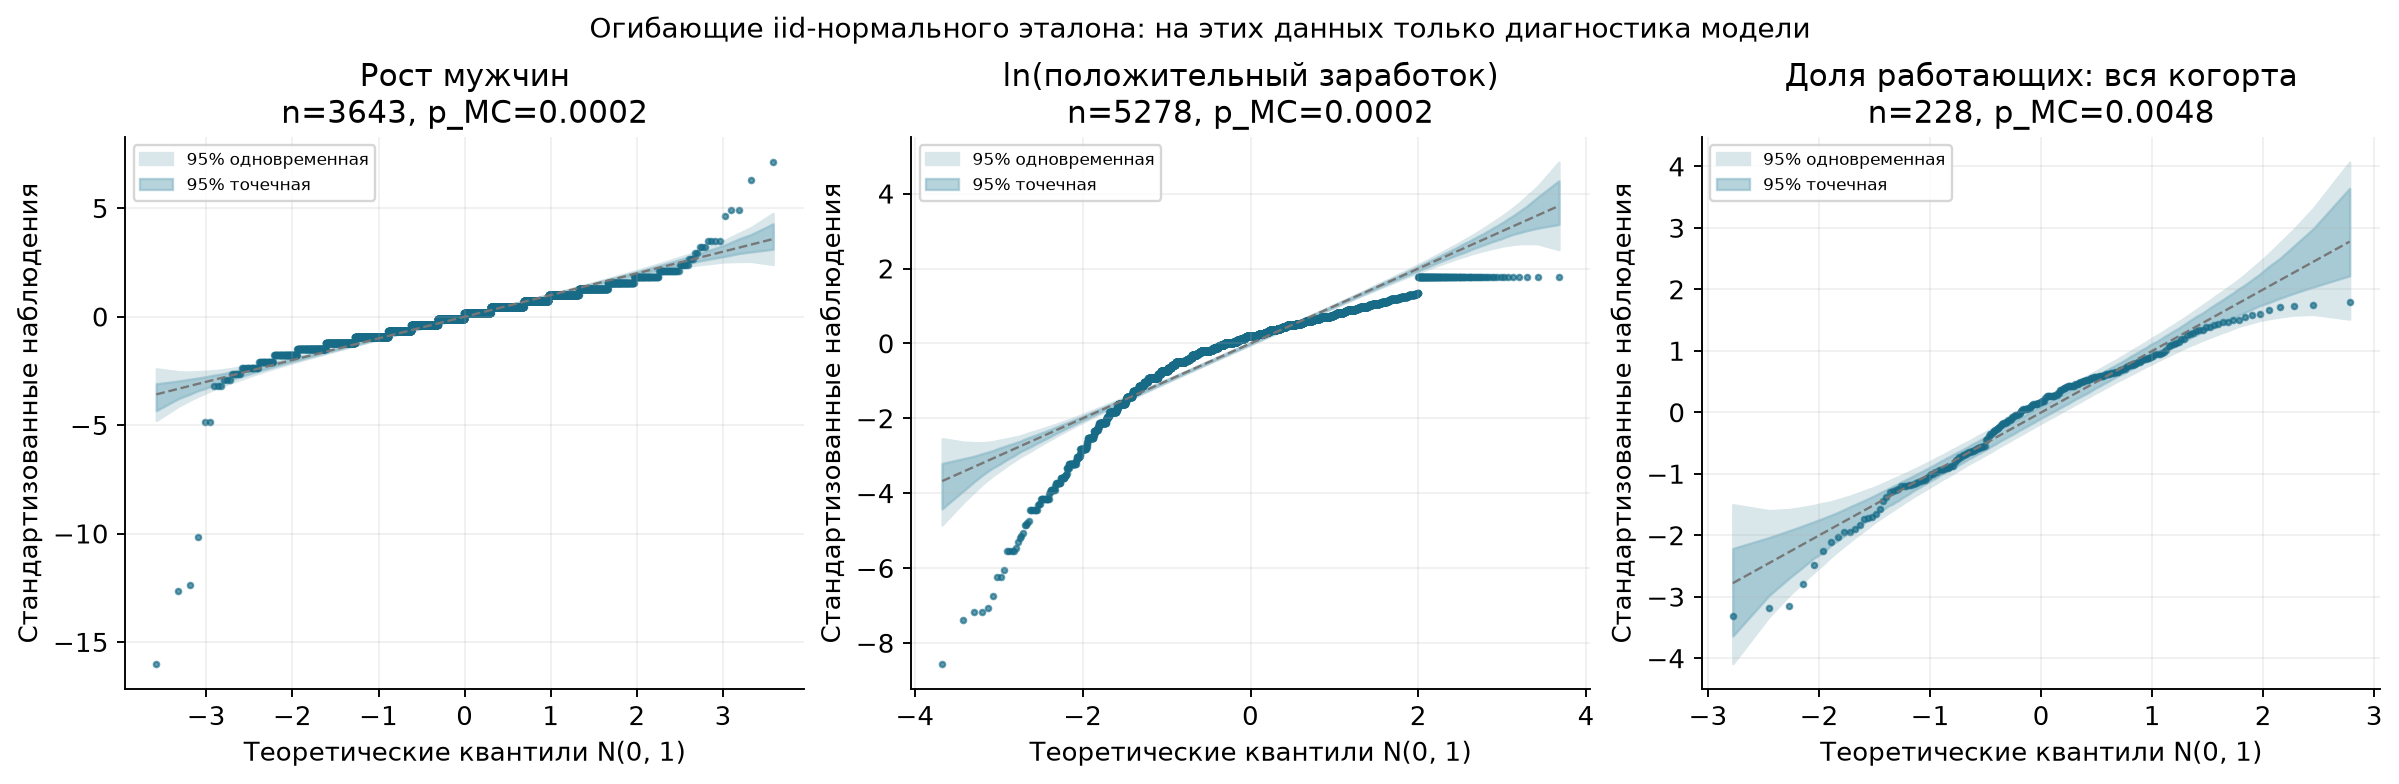

,sample,n,pvalue,statistic,critical
0,height_male,3643,0.0002,53.4787,3.7382
1,log_positive_wage,5278,0.0002,37.0285,3.7223
2,employment_level,228,0.0048,4.3873,3.5111


In [20]:
def normality_analysis(nls, employment, simulations=4999):
    samples={
        'height_male':nls.loc[nls.sex.eq('Male'),'height_cm'].dropna().to_numpy(),
        'weight_all':nls.weight_kg.dropna().to_numpy(),
        'log_positive_wage':np.log(nls.loc[nls.wage_income_2010_usd.gt(0),'wage_income_2010_usd']).to_numpy(),
        'employment_level':employment.employment_all.dropna().to_numpy(),
        'employment_difference':employment.employment_all.diff().dropna().to_numpy(),
    }
    rows=[]; selection=[]
    for name,x in samples.items():
        rng=np.random.default_rng(SEED)
        perm=rng.permutation(len(x))
        sizes=sorted(set([s for s in [20,50,200,1000,5000] if s<=len(x)]+[len(x)]))
        for n in sizes:
            chosen=x[perm[:n]]
            result=normality_tests(chosen,simulations=simulations)
            result['sample']=name
            result['unique_fraction']=len(np.unique(chosen))/n
            result['scope']='iid-калибровка неприменима к зависимым месяцам' if name.startswith('employment') else 'iid-ориентир: дизайн опроса и округление не учтены'
            rows.append(result)
            selection.extend(dict(sample=name,n=n,position=int(p)) for p in perm[:n])
    results=pd.concat(rows,ignore_index=True)
    results['p_holm_within_sample_size']=np.nan
    for _,idx in results.groupby(['sample','n']).groups.items():
        valid=results.loc[idx,'pvalue'].notna()
        vi=results.loc[idx].index[valid]
        results.loc[vi,'p_holm_within_sample_size']=multipletests(results.loc[vi,'pvalue'],method='holm')[1]
    table(results,'normality_tests');table(pd.DataFrame(selection),'normality_subsamples')
    envelopes=[]
    fig,axes=plt.subplots(1,3,figsize=(14,4.5),layout='constrained')
    fig.suptitle('Огибающие iid-нормального эталона: на этих данных только диагностика модели',fontsize=12)
    labels={'height_male':'Рост мужчин','log_positive_wage':'ln(положительный заработок)','employment_level':'Доля работающих: вся когорта'}
    for ax,name in zip(axes,labels):
        x=samples[name]
        e=qq_envelope(x,simulations=simulations)
        q=e['theoretical']
        ax.fill_between(q,e['global_lo'],e['global_hi'],color='#D9E6EA',label='95% одновременная')
        ax.fill_between(q,e['point_lo'],e['point_hi'],color='#88B8C7',alpha=.6,label='95% точечная')
        ax.plot(q,q,color='#777777',ls='--',lw=1)
        ax.scatter(q,e['observed'],s=5,color=COLORS[0],alpha=.65)
        ax.set(xlabel='Теоретические квантили N(0, 1)',ylabel='Стандартизованные наблюдения',title=labels[name]+f'\nn={len(x)}, p_MC={e["pvalue"]:.4f}')
        ax.legend(fontsize=7,loc='upper left')
        table(pd.DataFrame({k:e[k] for k in ['theoretical','observed','center','point_lo','point_hi','global_lo','global_hi']}),f'qq_{name}')
        envelopes.append(dict(sample=name,n=len(x),pvalue=e['pvalue'],statistic=e['statistic'],critical=e['critical']))
    figure(fig,'08_qq_envelopes')
    table(pd.DataFrame(envelopes),'qq_envelope_tests')
    # Характер зависимости p от n: нет нового поиска "удачной" подвыборки.
    fig,ax=plt.subplots(figsize=(9,4.8),layout='constrained')
    for name in ['height_male','weight_all','log_positive_wage']:
        a=results[results['sample'].eq(name)&results.method.eq('Shapiro–Wilk')].dropna(subset=['pvalue'])
        ax.plot(a.n,np.maximum(a.pvalue,1e-30),'-o',label=name)
    ax.axhline(.05,color=COLORS[1],ls='--',label='α = 0.05')
    ax.set(xscale='log',yscale='log',ylim=(1e-30,1),xlabel='Размер вложенной подвыборки',ylabel='p-value (значения ниже 10⁻³⁰ показаны на границе)',title='Шапиро–Уилк: размер выборки меняет чувствительность')
    ax.legend(fontsize=9)
    figure(fig,'09_normality_sizes')
    return dict(results=results,envelopes=pd.DataFrame(envelopes))

normality = normality_analysis(nls, employment, simulations=4999)
show_figure("08_qq_envelopes")
display(normality["envelopes"])


,sample,n,method,statistic,pvalue,note,scope
20,height_male,3643,Lilliefors,0.0828,1.0000e-03,p<=0.001 (граница таблицы),iid-ориентир: дизайн опроса и округление не учтены
21,height_male,3643,Shapiro–Wilk,0.8696,5.7344e-48,"аппроксимация p, n<=5000",iid-ориентир: дизайн опроса и округление не учтены
22,height_male,3643,Shapiro–Francia,0.8675,2.7017e-45,"Royston, 5<=n<=5000",iid-ориентир: дизайн опроса и округление не учтены
23,height_male,3643,Anderson–Darling,30.7752,2.0000e-04,"устойчивая log-CDF; MC с переоценкой параметров, B=4999",iid-ориентир: дизайн опроса и округление не учтены
24,height_male,3643,Cramér–von Mises,4.7166,2.0000e-04,"параметрический MC, B=4999; min p=0.0002",iid-ориентир: дизайн опроса и округление не учтены
50,weight_all,7186,Lilliefors,0.0863,1.0000e-03,p<=0.001 (граница таблицы),iid-ориентир: дизайн опроса и округление не учтены
51,weight_all,7186,Shapiro–Wilk,NaN,NaN,не вычисляем p: n>5000; см. явные подвыборки,iid-ориентир: дизайн опроса и округление не учтены
52,weight_all,7186,Shapiro–Francia,NaN,NaN,не вычисляем p: n>5000; см. явные подвыборки,iid-ориентир: дизайн опроса и округление не учтены
53,weight_all,7186,Anderson–Darling,78.3871,2.0000e-04,"устойчивая log-CDF; MC с переоценкой параметров, B=4999",iid-ориентир: дизайн опроса и округление не учтены
54,weight_all,7186,Cramér–von Mises,12.4591,2.0000e-04,"параметрический MC, B=4999; min p=0.0002",iid-ориентир: дизайн опроса и округление не учтены


,n,method,pvalue,p_holm_within_sample_size,unique_fraction
0,20,Lilliefors,1.7668e-01,8.6238e-01,0.4500
1,20,Shapiro–Wilk,1.7248e-01,8.6238e-01,0.4500
2,20,Shapiro–Francia,3.0808e-01,8.6238e-01,0.4500
3,20,Anderson–Darling,2.5000e-01,8.6238e-01,0.4500
4,20,Cramér–von Mises,2.7000e-01,8.6238e-01,0.4500
5,50,Lilliefors,9.2756e-03,4.6378e-02,0.2600
6,50,Shapiro–Wilk,2.4968e-02,7.4905e-02,0.2600
7,50,Shapiro–Francia,4.6817e-02,7.4905e-02,0.2600
8,50,Anderson–Darling,1.7200e-02,6.8800e-02,0.2600
9,50,Cramér–von Mises,2.5400e-02,7.4905e-02,0.2600


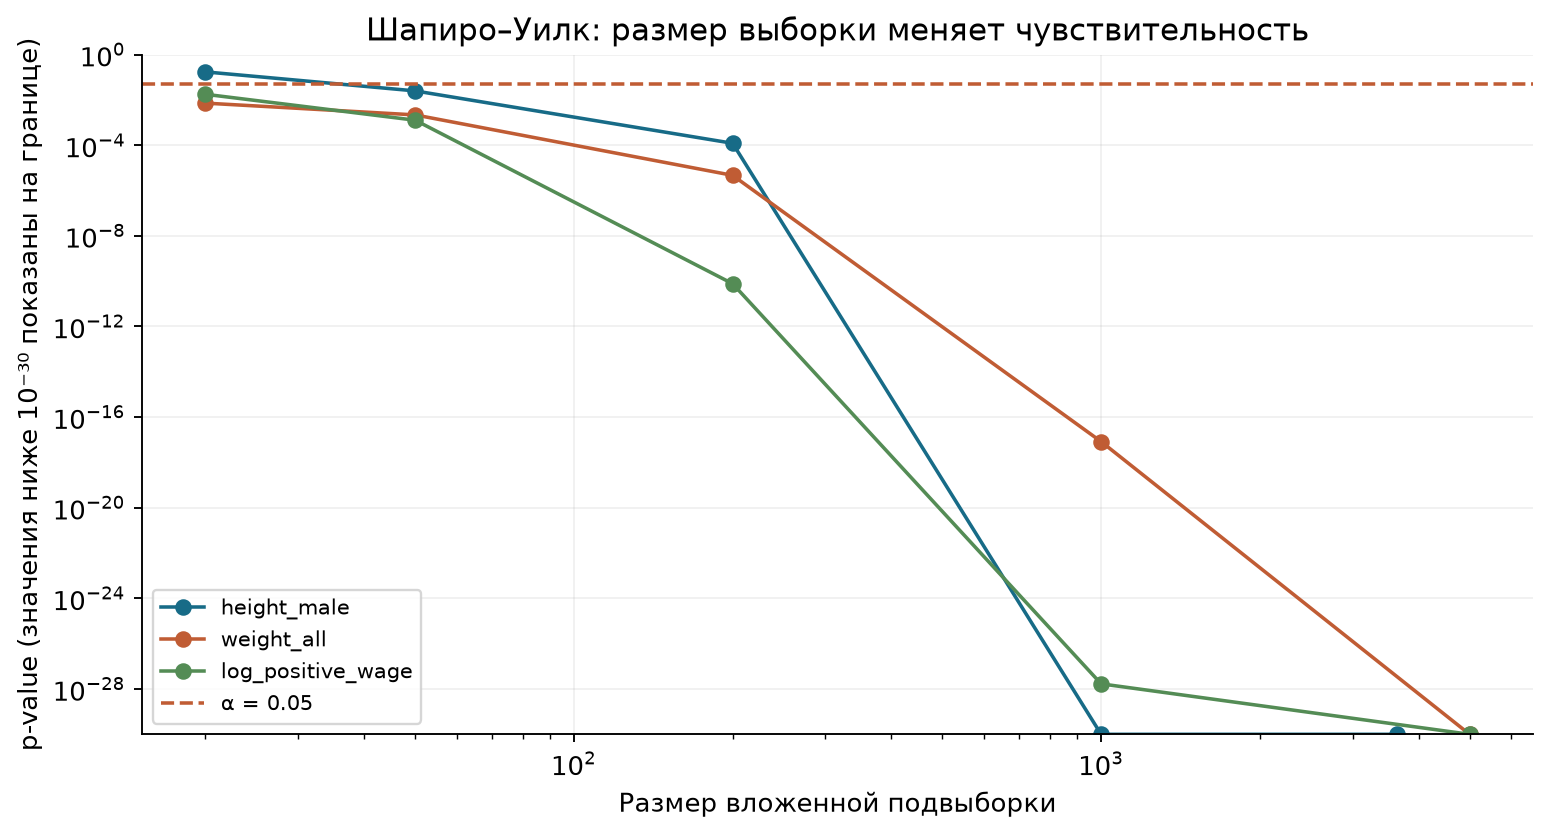

In [21]:
tests = normality["results"]
# Последняя (полная) выборка каждого признака. NaN для SW/SF при n>5000 намеренны.
display(tests.groupby(["sample", "method"], sort=False).tail(1)[
    ["sample", "n", "method", "statistic", "pvalue", "note", "scope"]])
display(tests.query("sample == 'height_male'")[
    ["n", "method", "pvalue", "p_holm_within_sample_size", "unique_fraction"]])
show_figure("09_normality_sizes")


У роста выделяется нижний хвост, у логарифма заработка остаются асимметрия и площадка сверху, а ряд занятости содержит тренд и зависимые месяцы. При большом n критерии чувствительны даже к небольшим отклонениям. p ≥ 0.05 не доказывает нормальность.

Поправка Holm применяется только к пяти тестам одного признака при одном n и не исправляет зависимость наблюдений.

### Влияние объёма выборки: симуляция

Для нормального, t₅ и логнормального распределений выполняется по 1000 повторов при n = 20, 50, 200, 1000. На нормальных данных доля отклонений оценивает ошибку I рода, на остальных — мощность. Это отдельный опыт на независимых синтетических данных.


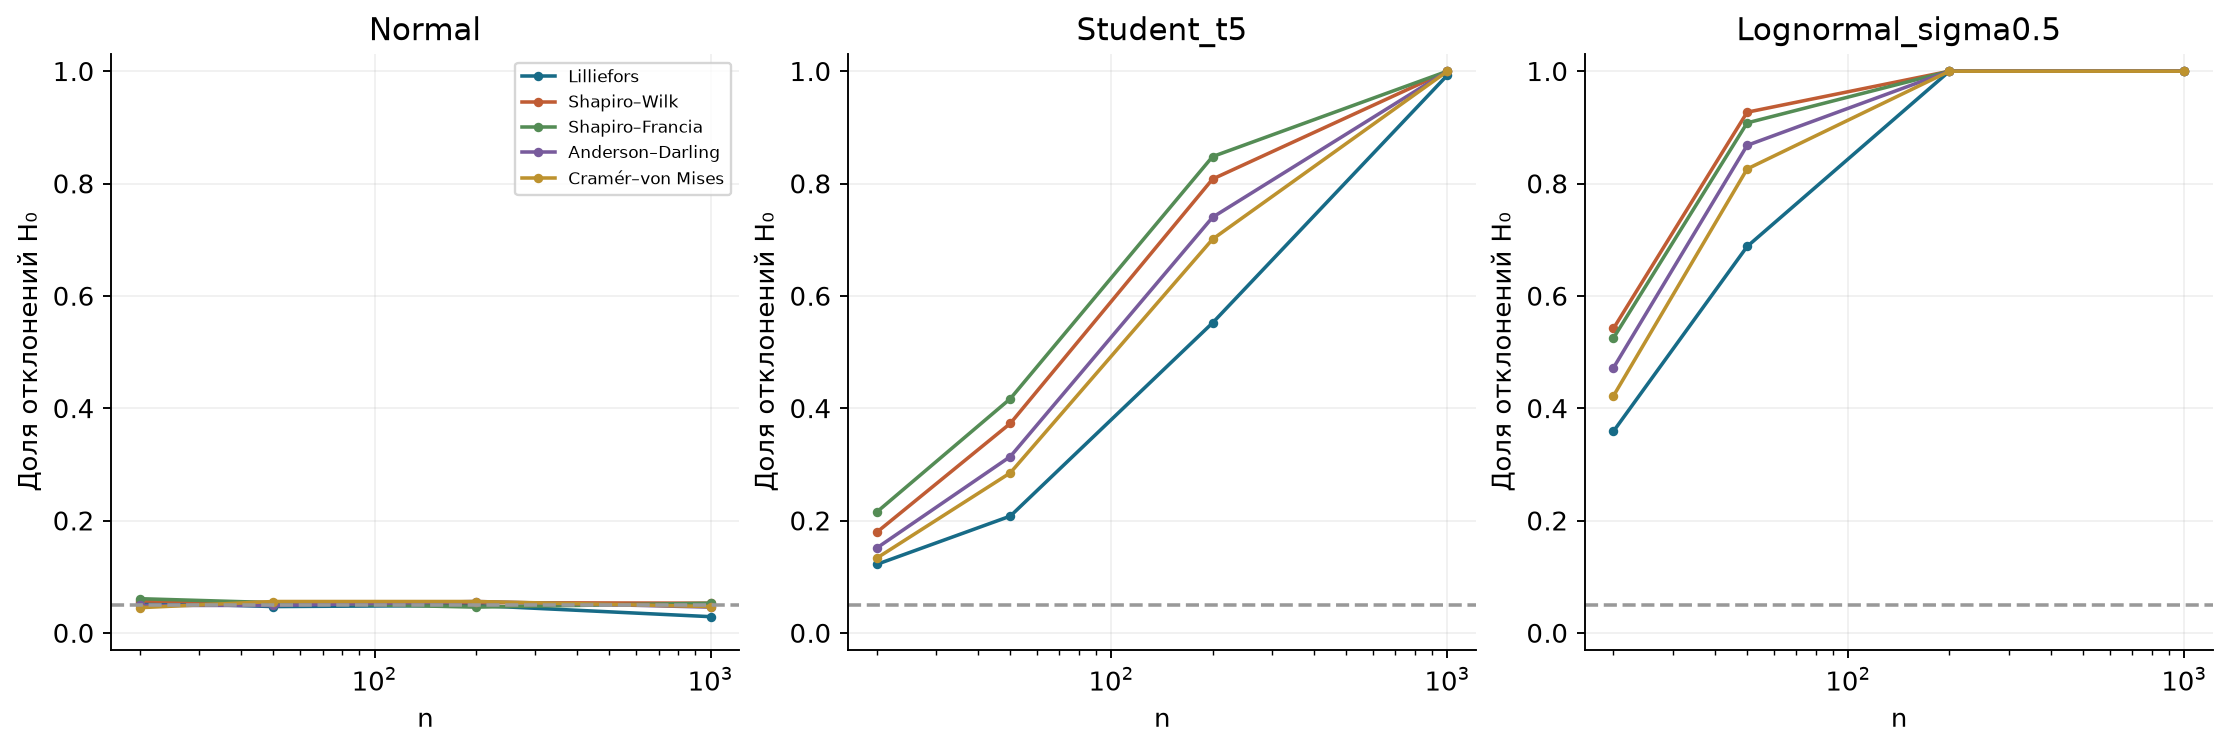

,n,distribution,method,reject_rate,ci_low,ci_high,repeats
0,20,Normal,Lilliefors,0.054,0.0416,0.0698,1000
1,20,Normal,Shapiro–Wilk,0.057,0.0443,0.0731,1000
2,20,Normal,Shapiro–Francia,0.061,0.0478,0.0776,1000
3,20,Normal,Anderson–Darling,0.049,0.0373,0.0642,1000
4,20,Normal,Cramér–von Mises,0.045,0.0338,0.0597,1000
15,50,Normal,Lilliefors,0.047,0.0355,0.0619,1000
16,50,Normal,Shapiro–Wilk,0.054,0.0416,0.0698,1000
17,50,Normal,Shapiro–Francia,0.054,0.0416,0.0698,1000
18,50,Normal,Anderson–Darling,0.049,0.0373,0.0642,1000
19,50,Normal,Cramér–von Mises,0.056,0.0434,0.0720,1000


,n,distribution,method,reject_rate,ci_low,ci_high,repeats
6,20,Student_t5,Shapiro–Wilk,0.179,0.1565,0.2040,1000
21,50,Student_t5,Shapiro–Wilk,0.373,0.3436,0.4034,1000
36,200,Student_t5,Shapiro–Wilk,0.808,0.7824,0.8312,1000
51,1000,Student_t5,Shapiro–Wilk,1.000,0.9962,1.0000,1000


In [22]:
def normality_simulation(repeats=1000, simulations=4999):
    """Отдельный учебный iid-эксперимент: уровень и мощность, не реальные данные.

    Для каждого размера и закона ровно 1000 заранее заданных реализаций.
    Все методы получают одни и те же выборки. Цель — увидеть размер эффекта n.
    """
    rng=np.random.default_rng(SEED+1234)
    rows=[]
    for n in [20,50,200,1000]:
        for distribution in ['Normal','Student_t5','Lognormal_sigma0.5']:
            hits={}
            for _ in range(repeats):
                if distribution=='Normal': x=rng.normal(size=n)
                elif distribution=='Student_t5': x=rng.standard_t(5,size=n)
                else: x=rng.lognormal(sigma=.5,size=n)
                result=normality_tests(x,simulations=simulations)
                for row in result.itertuples():
                    hits[row.method]=hits.get(row.method,0)+int(row.pvalue<.05)
            for method,count in hits.items():
                ci=stats.binomtest(count,repeats).proportion_ci(confidence_level=.95,method='wilson')
                rows.append(dict(n=n,distribution=distribution,method=method,reject_rate=count/repeats,
                                 ci_low=ci.low,ci_high=ci.high,repeats=repeats))
    results=table(pd.DataFrame(rows),'normality_simulation')
    fig,axes=plt.subplots(1,3,figsize=(13,4.3),layout='constrained')
    for ax,distribution in zip(axes,['Normal','Student_t5','Lognormal_sigma0.5']):
        for method,g in results[results.distribution.eq(distribution)].groupby('method',sort=False):
            ax.plot(g.n,g.reject_rate,'-o',ms=3,label=method)
        ax.axhline(.05,color='#999999',ls='--')
        ax.set(xscale='log',ylim=(-.03,1.03),xlabel='n',ylabel='Доля отклонений H₀',title=distribution)
    axes[0].legend(fontsize=7)
    figure(fig,'10_normality_simulation')
    return results

simulation = normality_simulation(repeats=1000, simulations=4999)
show_figure("10_normality_simulation")
display(simulation.query("distribution == 'Normal'"))
display(simulation.query("distribution == 'Student_t5' and method == 'Shapiro–Wilk'"))


С ростом n мощность увеличивается. На нормальных данных частота отклонений колеблется около заданных 5%; интервалы Уилсона показывают погрешность оценки. Результаты сравнения относятся к выбранным распределениям.

### Итоги

- Доходы асимметричны, содержат нули и обработанный поставщиком верхний хвост.
- Разные методы выделяют разные выбросы; автоматическое удаление записей не выполнялось.
- Лучший способ заполнения зависит от признака и характера пропусков.
- При проверке нормальности нужно учитывать графики, объём выборки и зависимость наблюдений.

### Источники

Данные: [NLSY97](https://www.bls.gov/nls/nlsy97.htm), [коды истории занятости](https://www.nlsinfo.org/content/cohorts/nlsy97/other-documentation/codebook-supplement/appendix-6-event-history-creation-and-documentation), [календарь недель](https://nlsinfo.org/content/cohorts/nlsy97/other-documentation/codebook-supplement/appendix-7-continuous-month-scheme), [локальные файлы](datasets/README.md).

Методы: [Граббс](https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h1.htm), [Диксон](https://itl.nist.gov/div898/software/dataplot/refman1/auxillar/dixon.htm), [SciPy](https://docs.scipy.org/doc/scipy/reference/stats.html), [scikit-learn](https://scikit-learn.org/stable/modules/impute.html), [Лиллиефорс](https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.lilliefors.html), [Шапиро–Франсия: реализация nortest](https://raw.githubusercontent.com/cran/nortest/master/R/sf.test.R).
